# CZ Benchmark Evaluation for GenePT Model

This notebook implements the CZ benchmark adaptation for evaluating the GenePT cell type classification model.

Based on the specification in `specs/cz_benchmark_adaptation_spec.md`, we'll:
1. Load the best pre-trained model from WandB (run: nwhis8xb)
2. Adapt it for benchmark datasets using transfer learning
3. Perform 5-fold cross-validation
4. Compare with baseline classifiers
5. Track all experiments with WandB

In [42]:
# Setup notebook environment
%load_ext autoreload
%autoreload 2

import sys
import os
from pathlib import Path

# Add parent directory to path
repo_dir = Path.cwd().parent
if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))

print(f"Repository directory: {repo_dir}")
data_dir = repo_dir / "data"
print(f"Data directory: {data_dir}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Repository directory: /Users/rj/personal/GenePT-tools
Data directory: /Users/rj/personal/GenePT-tools/data


In [43]:
# Import required libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import wandb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder
import scanpy as sc
import anndata as ad
from tqdm.auto import tqdm
import copy
from dataclasses import dataclass, field
from typing import Optional, Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Import GenePT modules
from src.models.mlp_classifier import MLPClassifier
from src.inference import create_embedding_matrix, create_cell_embeddings
from src.training.metrics import evaluate_with_hierarchy
from src.training.ontology import CellOntologyManager

## 1. Configuration

In [44]:
@dataclass
class AdaptationConfig:
    """Configuration for model adaptation and fine-tuning."""
    
    # Base model reference
    base_wandb_run: str = "nwhis8xb"
    base_project: str = "honicky/cellxgene-mlp-v1"
    
    # Model adaptation
    freeze_base_model: bool = True
    use_adapter_layer: bool = False
    adapter_dropout: float = 0.042  # Match base model dropout
    
    # Training parameters (tuned from base)
    adaptation_lr: float = 5e-4  # ~40% of base LR
    weight_decay: float = 1e-5
    batch_size: int = 1024  # Match base model
    max_adaptation_epochs: int = 100
    patience: int = 3
    
    # Validation strategy
    validation_split: float = 0.2  # From training fold
    min_delta: float = 0.001  # Minimum improvement
    
    # Learning rate scheduling
    use_lr_scheduler: bool = True
    scheduler_type: str = "cosine"  # or "step"
    scheduler_params: dict = field(default_factory=lambda: {
        "T_max": 10,  # for cosine
        "eta_min": 1e-5
    })
    
    # WandB tracking
    wandb_project: str = "cz-benchmark-genept"
    wandb_entity: Optional[str] = None
    
    # Data parameters
    min_cells_per_type: int = 10
    n_folds: int = 5
    random_seed: int = 42
    
    # Device
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

config = AdaptationConfig()
print(f"Configuration loaded. Using device: {config.device}")

Configuration loaded. Using device: cpu


## 2. Load Base Model from WandB

In [45]:
def load_best_genept_model(config: AdaptationConfig) -> Tuple[MLPClassifier, Dict]:
    """Load the best pre-trained GenePT model from WandB."""
    
    print(f"Loading model from WandB run: {config.base_project}/{config.base_wandb_run}")
    
    # Initialize WandB API
    api = wandb.Api()
    run = api.run(f"{config.base_project}/{config.base_wandb_run}")
    
    # Get configuration
    run_config = run.config
    
    # Handle both nested and flat config structures
    if isinstance(run_config.get('input_dim'), dict):
        input_dim = run_config['input_dim']['value']
        num_classes = run_config['num_classes']['value']
        n_hidden_layers = run_config['n_hidden_layers']['value']
        dropout = run_config['dropout']['value']
    else:
        input_dim = run_config.get('input_dim', 500)
        num_classes = run_config.get('num_classes', 377)
        n_hidden_layers = run_config.get('n_hidden_layers', 3)
        dropout = run_config.get('dropout', 0.053)
    
    print(f"Model configuration:")
    print(f"  - Input dim: {input_dim}")
    print(f"  - Num classes: {num_classes}")
    print(f"  - Hidden layers: {n_hidden_layers}")
    print(f"  - Dropout: {dropout}")
    
    # Download checkpoint artifact
    artifacts = run.logged_artifacts()
    checkpoint_artifacts = [a for a in artifacts if 'checkpoint' in a.name]
    
    if not checkpoint_artifacts:
        # Try to find model files directly
        print("No checkpoint artifacts found, looking for model files...")
        checkpoint_path = None
        for file in run.files():
            if file.name.endswith('.pt'):
                print(f"Found model file: {file.name}")
                file.download(root="./wandb_downloads", replace=True)
                checkpoint_path = f"./wandb_downloads/{file.name}"
                break
        if not checkpoint_path:
            raise ValueError("No model checkpoint found in WandB run")
    else:
        artifact = checkpoint_artifacts[-1]  # Get latest/best
        print(f"Downloading artifact: {artifact.name}")
        artifact_dir = artifact.download()
        
        # Find the .pt file
        checkpoint_files = [f for f in os.listdir(artifact_dir) if f.endswith('.pt')]
        if not checkpoint_files:
            raise ValueError(f"No .pt files found in artifact directory: {artifact_dir}")
        checkpoint_path = os.path.join(artifact_dir, checkpoint_files[0])
    
    # Initialize model with original configuration
    model = MLPClassifier(
        input_dim=input_dim,
        num_classes=num_classes,
        n_hidden_layers=n_hidden_layers,
        dropout=dropout
    )
    
    # Load checkpoint
    print(f"Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=config.device, weights_only=False)
    
    # Handle different checkpoint formats
    if isinstance(checkpoint, dict):
        if 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        else:
            # Might be the state dict directly
            state_dict = checkpoint
        
        # Check if we need to add "model." prefix
        sample_key = list(state_dict.keys())[0] if state_dict else ""
        if not sample_key.startswith("model."):
            # Need to add "model." prefix to all keys
            new_state_dict = {}
            for key, value in state_dict.items():
                new_state_dict[f"model.{key}"] = value
            state_dict = new_state_dict
        
        model.load_state_dict(state_dict)
    else:
        # Checkpoint might be the model itself
        model = checkpoint
    
    model = model.to(config.device)
    print("Model loaded successfully!")
    
    # Return config in consistent format
    config_dict = {
        'input_dim': {'value': input_dim},
        'num_classes': {'value': num_classes},
        'n_hidden_layers': {'value': n_hidden_layers},
        'dropout': {'value': dropout}
    }
    
    return model, config_dict

# Load the base model
base_model, base_config = load_best_genept_model(config)

Loading model from WandB run: honicky/cellxgene-mlp-v1/nwhis8xb
Model configuration:
  - Input dim: 500
  - Num classes: 377
  - Hidden layers: 3
  - Dropout: 0.05310516410376493
No checkpoint artifacts found, looking for model files...
Found model file: nwhis8xb/mlp_checkpoint_1000.pt
Loading checkpoint from: ./wandb_downloads/nwhis8xb/mlp_checkpoint_1000.pt
Model loaded successfully!


## 3. Model Adaptation Module

In [46]:
class ModelAdapter:
    """Adapt pre-trained model for new cell type sets."""
    
    @staticmethod
    def create_adapted_model(
        base_model: MLPClassifier,
        num_target_classes: int,
        config: AdaptationConfig
    ) -> MLPClassifier:
        """
        Create task-specific model from pre-trained base.
        """
        # Deep copy to avoid modifying original
        model = copy.deepcopy(base_model)
        
        # Get the last linear layer's input features
        # The model.model is nn.Sequential, get second-to-last layer's output
        for i, layer in enumerate(model.model):
            if isinstance(layer, nn.Linear) and i < len(model.model) - 1:
                last_hidden_dim = layer.out_features
        
        # Freeze all but output layer if specified
        if config.freeze_base_model:
            for i, param in enumerate(model.model.parameters()):
                # Don't freeze the last linear layer's parameters
                if i < len(list(model.model.parameters())) - 2:  # -2 for weight and bias
                    param.requires_grad = False
        
        # Replace output layer
        if config.use_adapter_layer:
            # Add adapter layer
            adapter_dim = (last_hidden_dim + num_target_classes) // 2
            new_output = nn.Sequential(
                nn.Linear(last_hidden_dim, adapter_dim),
                nn.BatchNorm1d(adapter_dim),
                nn.ReLU(),
                nn.Dropout(config.adapter_dropout),
                nn.Linear(adapter_dim, num_target_classes)
            )
        else:
            # Direct replacement
            new_output = nn.Linear(last_hidden_dim, num_target_classes)
        
        # Replace the last layer
        model.model[-1] = new_output
        model.num_classes = num_target_classes
        
        return model.to(config.device)

# Test the adapter
print("Testing model adaptation...")
test_adapted_model = ModelAdapter.create_adapted_model(base_model, 50, config)
print(f"Adapted model output dimension: {test_adapted_model.num_classes}")
del test_adapted_model  # Clean up

Testing model adaptation...
Adapted model output dimension: 50


## 4. Data Processing Module

In [77]:
class CZBenchmarkDataProcessor:
    """Process benchmark datasets for GenePT evaluation."""
    
    def __init__(self, config: AdaptationConfig, embedding_dim: int = 500):
        self.config = config
        self.embedding_dim = embedding_dim
        self.gene_embeddings = None
        self.label_encoder = LabelEncoder()
        self.filtered_indices = None  # Track which cells are kept after filtering
    
    def load_gene_embeddings(self, embedding_path: Optional[Path] = None):
        """Load pre-computed GenePT gene embeddings."""
        if embedding_path is None:
            # Use the correct path to the embeddings file
            embedding_path = data_dir / "huggingface_model" / "embedding_associations_cell_type_tissue_drug_pathway_openai_large.parquet"
        
        print(f"Loading gene embeddings from: {embedding_path}")
        embeddings_df = pd.read_parquet(embedding_path)
        
        # The gene names are in the index
        if embeddings_df.index.name == 'gene_name':
            # Select embedding columns (first embedding_dim columns)
            embedding_cols = [str(i) for i in range(min(self.embedding_dim, len(embeddings_df.columns)))]
            self.gene_embeddings = embeddings_df[embedding_cols]
            # Reset index to have gene_name as a column for compatibility
            self.gene_embeddings = self.gene_embeddings.reset_index()
        else:
            # Fall back to looking for a gene_name column
            if 'gene_name' in embeddings_df.columns:
                embedding_cols = [str(i) for i in range(min(self.embedding_dim, len(embeddings_df.columns) - 1))]
                self.gene_embeddings = embeddings_df[['gene_name'] + embedding_cols]
            else:
                raise ValueError("Gene embeddings file must have gene names in index or 'gene_name' column")
        
        print(f"Loaded embeddings for {len(self.gene_embeddings)} genes")
        print(f"Embedding dimension: {len(self.gene_embeddings.columns) - 1}")  # -1 for gene_name column
        return self.gene_embeddings
    
    def prepare_dataset(
        self,
        adata: ad.AnnData,
        cell_type_col: str = 'cell_type'
    ) -> Tuple[np.ndarray, np.ndarray, List[str]]:
        """
        Process AnnData object for benchmark evaluation.
        
        Returns:
            X: Cell embeddings (n_cells, embedding_dim)
            y: Cell type labels (n_cells,)
            cell_types: List of unique cell types
        """
        print(f"Processing dataset with {adata.n_obs} cells and {adata.n_vars} genes")
        
        # Store original indices before filtering
        original_indices = np.arange(len(adata.obs))
        
        # Filter rare cell types
        cell_type_counts = adata.obs[cell_type_col].value_counts()
        valid_types = cell_type_counts[cell_type_counts >= self.config.min_cells_per_type].index
        
        print(f"Filtering {len(cell_type_counts) - len(valid_types)} rare cell types")
        
        # Create filter mask and apply it
        filter_mask = adata.obs[cell_type_col].isin(valid_types)
        adata = adata[filter_mask]
        
        # Store which cells were kept (indices into the original data)
        self.filtered_indices = original_indices[filter_mask]
        
        print(f"After filtering: {adata.n_obs} cells, {len(valid_types)} cell types")
        
        # Create gene embedding matrix
        if self.gene_embeddings is None:
            self.load_gene_embeddings()
        
        # Process gene names to handle mixed formats in feature_name column
        if 'feature_name' in adata.var.columns:
            gene_list = []
            for gene in adata.var['feature_name']:
                # Handle different formats:
                # 1. "GENE_ENSG00000123456" -> extract "GENE"
                # 2. "ENSG00000123456.15" -> use as-is (will likely not match)
                # 3. "GENE" -> use as-is
                if '_ENSG' in gene:
                    # Extract gene symbol before _ENSG
                    gene_symbol = gene.split('_ENSG')[0]
                    gene_list.append(gene_symbol)
                else:
                    # Use as-is for normal gene symbols or ENSG IDs
                    gene_list.append(gene)
            print(f"Processed feature_name column for gene symbols")
            print(f"Example genes after processing: {gene_list[:5]}")
        else:
            # Use the index directly
            gene_list = adata.var_names.tolist()
        
        # Align gene embeddings with expression data
        # create_embedding_matrix returns tuple of (embedding_matrix, valid_indices)
        embedding_matrix, valid_indices = create_embedding_matrix(
            self.gene_embeddings,
            gene_list,
            id_column='gene_name'
        )
        
        print(f"Valid genes matched: {len(valid_indices)} out of {len(gene_list)}")
        
        # Check if we have any valid genes
        if len(valid_indices) == 0:
            raise ValueError("No genes matched between dataset and embeddings!")
        
        # Create cell embeddings
        print("Creating cell embeddings...")
        X = create_cell_embeddings(
            adata.X,
            embedding_matrix,
            valid_indices  # Pass the valid_indices instead of use_torch
        )
        
        # Encode labels
        cell_types = adata.obs[cell_type_col].values
        y = self.label_encoder.fit_transform(cell_types)
        
        # Scale embeddings (important for OpenAI embeddings)
        X = X / 0.026  # As per GenePT training
        
        return X, y, self.label_encoder.classes_.tolist()

# Initialize data processor
data_processor = CZBenchmarkDataProcessor(
    config,
    embedding_dim=base_config['input_dim']['value']  # 500
)

## 5. Training and Evaluation Module

In [48]:
class AdaptiveTrainer:
    """Fine-tuning trainer with early stopping and WandB tracking."""
    
    def __init__(self, config: AdaptationConfig):
        self.config = config
        self.device = torch.device(config.device)
    
    def train_epoch(
        self,
        model: MLPClassifier,
        train_loader: DataLoader,
        optimizer: optim.Optimizer,
        criterion: nn.Module
    ) -> float:
        """Train for one epoch."""
        model.train()
        total_loss = 0
        
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(self.device)
            batch_y = batch_y.to(self.device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        return total_loss / len(train_loader)
    
    def evaluate(
        self,
        model: MLPClassifier,
        val_loader: DataLoader,
        criterion: nn.Module
    ) -> Dict[str, float]:
        """Evaluate model on validation set."""
        model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X = batch_X.to(self.device)
                batch_y = batch_y.to(self.device)
                
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                total_loss += loss.item()
                
                preds = outputs.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(batch_y.cpu().numpy())
        
        # Calculate metrics
        metrics = {
            'loss': total_loss / len(val_loader),
            'accuracy': accuracy_score(all_labels, all_preds),
            'f1_macro': f1_score(all_labels, all_preds, average='macro', zero_division=0),
            'precision_macro': precision_score(all_labels, all_preds, average='macro', zero_division=0),
            'recall_macro': recall_score(all_labels, all_preds, average='macro', zero_division=0)
        }
        
        return metrics
    
    def train_fold(
        self,
        model: MLPClassifier,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_val: np.ndarray,
        y_val: np.ndarray,
        fold_idx: int,
        dataset_name: str,
        use_wandb: bool = True
    ) -> Tuple[MLPClassifier, Dict[str, float]]:
        """Train single fold with validation-based early stopping."""
        
        # Initialize WandB run for this fold
        if use_wandb:
            run = wandb.init(
                project=self.config.wandb_project,
                name=f"{dataset_name}_fold_{fold_idx}",
                config={
                    "base_model": self.config.base_wandb_run,
                    "dataset": dataset_name,
                    "fold": fold_idx,
                    "adaptation_lr": self.config.adaptation_lr,
                    "batch_size": self.config.batch_size,
                    "freeze_base": self.config.freeze_base_model,
                    "use_adapter": self.config.use_adapter_layer
                },
                reinit=True
            )
        
        # Create data loaders
        train_dataset = TensorDataset(
            torch.FloatTensor(X_train),
            torch.LongTensor(y_train)
        )
        val_dataset = TensorDataset(
            torch.FloatTensor(X_val),
            torch.LongTensor(y_val)
        )
        
        train_loader = DataLoader(
            train_dataset,
            batch_size=self.config.batch_size,
            shuffle=True
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=self.config.batch_size,
            shuffle=False
        )
        
        # Setup optimizer and criterion
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=self.config.adaptation_lr,
            weight_decay=self.config.weight_decay
        )
        criterion = nn.CrossEntropyLoss()
        
        # Setup learning rate scheduler if enabled
        scheduler = None
        if self.config.use_lr_scheduler:
            if self.config.scheduler_type == "cosine":
                scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer,
                    **self.config.scheduler_params
                )
        
        # Training loop
        best_val_loss = float('inf')
        best_model_state = None
        patience_counter = 0
        
        for epoch in range(self.config.max_adaptation_epochs):
            # Train
            train_loss = self.train_epoch(model, train_loader, optimizer, criterion)
            
            # Validate
            val_metrics = self.evaluate(model, val_loader, criterion)
            
            # Update scheduler
            if scheduler:
                scheduler.step()
            
            # Log to WandB
            if use_wandb:
                wandb.log({
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "val_loss": val_metrics['loss'],
                    "val_accuracy": val_metrics['accuracy'],
                    "val_f1_macro": val_metrics['f1_macro'],
                    "learning_rate": optimizer.param_groups[0]['lr']
                })
            
            print(f"Epoch {epoch}: Train Loss: {train_loss:.4f}, Val Loss: {val_metrics['loss']:.4f}, "
                  f"Val Acc: {val_metrics['accuracy']:.4f}, Val F1: {val_metrics['f1_macro']:.4f}")
            
            # Early stopping
            if val_metrics['loss'] < best_val_loss - self.config.min_delta:
                best_val_loss = val_metrics['loss']
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.config.patience:
                    print(f"Early stopping at epoch {epoch}")
                    break
        
        # Load best model
        if best_model_state:
            model.load_state_dict(best_model_state)
        
        # Final evaluation
        final_metrics = self.evaluate(model, val_loader, criterion)
        
        if use_wandb:
            wandb.finish()
        
        return model, final_metrics

# Initialize trainer
trainer = AdaptiveTrainer(config)

## 6. Cross-Validation Evaluation

In [49]:
class CrossValidationEvaluator:
    """5-fold cross-validation following CZ benchmark protocol."""
    
    def __init__(self, config: AdaptationConfig, base_model: MLPClassifier):
        self.config = config
        self.base_model = base_model
        self.trainer = AdaptiveTrainer(config)
        self.adapter = ModelAdapter()
    
    def run_cross_validation(
        self,
        X: np.ndarray,
        y: np.ndarray,
        cell_types: List[str],
        dataset_name: str,
        use_wandb: bool = True
    ) -> Dict:
        """Execute 5-fold stratified cross-validation with WandB tracking."""
        
        # Initialize main WandB run for summary
        if use_wandb:
            main_run = wandb.init(
                project=self.config.wandb_project,
                name=f"benchmark_{dataset_name}",
                config={
                    "base_model_run": self.config.base_wandb_run,
                    "dataset": dataset_name,
                    "n_folds": self.config.n_folds,
                    "n_samples": len(X),
                    "n_classes": len(cell_types),
                    "config": self.config.__dict__
                }
            )
        
        # Setup cross-validation
        cv = StratifiedKFold(
            n_splits=self.config.n_folds,
            shuffle=True,
            random_state=self.config.random_seed
        )
        
        fold_results = []
        
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
            print(f"\n=== Fold {fold_idx + 1}/{self.config.n_folds} ===")
            
            # Split data
            X_train_full, X_test = X[train_idx], X[test_idx]
            y_train_full, y_test = y[train_idx], y[test_idx]
            
            # Create validation split from training data
            train_idx_inner, val_idx_inner = train_test_split(
                np.arange(len(X_train_full)),
                test_size=self.config.validation_split,
                stratify=y_train_full,
                random_state=self.config.random_seed + fold_idx
            )
            
            X_train = X_train_full[train_idx_inner]
            X_val = X_train_full[val_idx_inner]
            y_train = y_train_full[train_idx_inner]
            y_val = y_train_full[val_idx_inner]
            
            print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
            
            # Adapt model for this fold
            adapted_model = self.adapter.create_adapted_model(
                self.base_model,
                num_target_classes=len(cell_types),
                config=self.config
            )
            
            # Train on fold
            trained_model, val_metrics = self.trainer.train_fold(
                adapted_model,
                X_train, y_train,
                X_val, y_val,
                fold_idx,
                dataset_name,
                use_wandb=use_wandb
            )
            
            # Evaluate on test fold
            test_dataset = TensorDataset(
                torch.FloatTensor(X_test),
                torch.LongTensor(y_test)
            )
            test_loader = DataLoader(
                test_dataset,
                batch_size=self.config.batch_size,
                shuffle=False
            )
            
            test_metrics = self.trainer.evaluate(
                trained_model,
                test_loader,
                nn.CrossEntropyLoss()
            )
            
            # Store results
            fold_result = {
                'fold': fold_idx,
                'val_metrics': val_metrics,
                'test_metrics': test_metrics
            }
            fold_results.append(fold_result)
            
            print(f"Test Metrics - Acc: {test_metrics['accuracy']:.4f}, "
                  f"F1: {test_metrics['f1_macro']:.4f}")
        
        # Aggregate results
        final_metrics = self.aggregate_metrics(fold_results)
        
        # Log summary to WandB
        if use_wandb:
            wandb.log({
                "final_accuracy_mean": final_metrics['accuracy']['mean'],
                "final_accuracy_std": final_metrics['accuracy']['std'],
                "final_f1_macro_mean": final_metrics['f1_macro']['mean'],
                "final_f1_macro_std": final_metrics['f1_macro']['std']
            })
            
            # Create summary table
            summary_table = wandb.Table(
                columns=["Fold", "Accuracy", "F1_Macro", "Precision", "Recall"],
                data=[
                    [
                        i,
                        r['test_metrics']['accuracy'],
                        r['test_metrics']['f1_macro'],
                        r['test_metrics']['precision_macro'],
                        r['test_metrics']['recall_macro']
                    ]
                    for i, r in enumerate(fold_results)
                ]
            )
            wandb.log({"fold_results": summary_table})
            wandb.finish()
        
        return final_metrics
    
    def aggregate_metrics(self, fold_results: List[Dict]) -> Dict:
        """Aggregate metrics across folds."""
        metrics_names = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']
        aggregated = {}
        
        for metric in metrics_names:
            values = [r['test_metrics'][metric] for r in fold_results]
            aggregated[metric] = {
                'mean': np.mean(values),
                'std': np.std(values),
                'per_fold': values
            }
        
        return aggregated

# Initialize evaluator
evaluator = CrossValidationEvaluator(config, base_model)

## 7. Load Tabula Sapiens v2 Benchmark Datasets

In [50]:
# Define benchmark data directory and tissues to evaluate
benchmark_dir = Path("/Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark")
tissues_to_evaluate = ["Blood", "Bone_Marrow", "Lung", "Mammary", "Thymus"]

def load_tabula_sapiens_dataset(tissue_name: str) -> ad.AnnData:
    """Load a Tabula Sapiens v2 curated benchmark dataset."""
    # Find the file for this tissue
    pattern = f"*_{tissue_name}_v2_curated.h5ad"
    files = list(benchmark_dir.glob(pattern))
    
    if not files:
        raise FileNotFoundError(f"No file found for tissue: {tissue_name}")
    
    file_path = files[0]
    print(f"Loading {tissue_name} from: {file_path}")
    print(f"File size: {file_path.stat().st_size / 1e9:.2f} GB")
    
    # Load the dataset
    adata = sc.read_h5ad(file_path)
    
    print(f"Dataset structure:")
    print(f"  - Shape: {adata.shape}")
    print(f"  - Layers: {list(adata.layers.keys()) if adata.layers else 'None'}")
    print(f"  - X matrix: {'Present' if adata.X is not None else 'None'}")
    
    # Check which layer contains the expression data
    if adata.X is None or (hasattr(adata.X, 'nnz') and adata.X.nnz == 0):
        print("X matrix is empty, checking layers...")
        
        # Common layer names for expression data - X_original is used in Tabula Sapiens v2
        expression_layers = ['X_original', 'counts', 'raw_counts', 'data', 'X', 'logcounts', 'normalized']
        
        for layer_name in expression_layers:
            if layer_name in adata.layers:
                print(f"Using layer '{layer_name}' as expression matrix")
                adata.X = adata.layers[layer_name].copy()  # Copy to avoid modifying the original layer
                break
        else:
            # If no standard name found, use the first available layer
            if adata.layers:
                first_layer = list(adata.layers.keys())[0]
                print(f"Using first available layer '{first_layer}' as expression matrix")
                adata.X = adata.layers[first_layer].copy()
            else:
                raise ValueError(f"No expression data found in X or layers for {tissue_name}")
    
    # Check if cell_type column exists, if not look for alternatives
    if 'cell_type' not in adata.obs.columns:
        # Try alternative column names
        for col in ['cell_ontology_class', 'celltype', 'CellType', 'cell_type_ontology', 'free_annotation']:
            if col in adata.obs.columns:
                adata.obs['cell_type'] = adata.obs[col]
                print(f"Using column '{col}' as cell_type")
                break
        else:
            # List available columns to help debug
            print(f"Available obs columns: {list(adata.obs.columns)[:10]}...")
            raise ValueError(f"No cell type column found in {tissue_name} dataset")
    
    print(f"Loaded {tissue_name}: {adata.n_obs} cells, {adata.n_vars} genes")
    print(f"Cell types: {adata.obs['cell_type'].nunique()}")
    
    # Check if data is sparse
    import scipy.sparse as sp
    if sp.issparse(adata.X):
        print(f"Data is sparse with {adata.X.nnz / (adata.X.shape[0] * adata.X.shape[1]) * 100:.2f}% non-zero elements")
        print(f"Memory usage (sparse): ~{adata.X.data.nbytes / 1e9:.2f} GB")
    else:
        print(f"Memory usage (dense): ~{adata.X.nbytes / 1e9:.2f} GB")
    
    return adata

# Test loading one dataset
print("Testing dataset loading...")
try:
    test_tissue = tissues_to_evaluate[0]
    test_adata = load_tabula_sapiens_dataset(test_tissue)
    print(f"\nSuccessfully loaded {test_tissue} dataset")
    print(f"Top 10 cell types by count:")
    print(test_adata.obs['cell_type'].value_counts().head(10))
    
    # Show some basic statistics
    print(f"\nExpression matrix statistics:")
    if hasattr(test_adata.X, 'data'):
        print(f"  - Min value: {test_adata.X.data.min():.2f}")
        print(f"  - Max value: {test_adata.X.data.max():.2f}")
        print(f"  - Mean value: {test_adata.X.data.mean():.2f}")
    else:
        print(f"  - Min value: {test_adata.X.min():.2f}")
        print(f"  - Max value: {test_adata.X.max():.2f}")
        print(f"  - Mean value: {test_adata.X.mean():.2f}")
    
    del test_adata  # Free memory
except Exception as e:
    print(f"Error loading dataset: {e}")
    import traceback
    traceback.print_exc()

Testing dataset loading...
Loading Blood from: /Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark/homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Blood_v2_curated.h5ad
File size: 0.69 GB
Dataset structure:
  - Shape: (17802, 27284)
  - Layers: ['X_original', 'decontXcounts', 'scale_data']
  - X matrix: Present
Loaded Blood: 17802 cells, 27284 genes
Cell types: 19
Data is sparse with 9.17% non-zero elements
Memory usage (sparse): ~0.18 GB

Successfully loaded Blood dataset
Top 10 cell types by count:
cell_type
neutrophil                         7927
classical monocyte                 2911
monocyte                           1230
intermediate monocyte               940
CD8-positive, alpha-beta T cell     914
B cell                              854
erythrocyte                         689
natural killer cell                 667
macrophage                          563
CD4-positive, alpha-beta T cell     498
Name: count, dtype: int64

Expression matrix statistics:
  - Min value: 1.00
  

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

def evaluate_baseline_classifiers(X, y, cell_types, n_folds=5):
    """Evaluate baseline classifiers for comparison."""
    
    classifiers = {
        'Logistic Regression': LogisticRegression(max_iter=1000, multi_class='ovr'),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
    }
    
    results = {}
    
    for clf_name, clf in classifiers.items():
        print(f"\nEvaluating {clf_name}...")
        
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
        fold_scores = []
        
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            # Scale features for LR and KNN
            if clf_name in ['Logistic Regression', 'K-Nearest Neighbors']:
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)
            
            # Train and predict
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            
            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
            
            fold_scores.append({'accuracy': accuracy, 'f1_macro': f1})
        
        # Aggregate results
        results[clf_name] = {
            'accuracy': {
                'mean': np.mean([s['accuracy'] for s in fold_scores]),
                'std': np.std([s['accuracy'] for s in fold_scores])
            },
            'f1_macro': {
                'mean': np.mean([s['f1_macro'] for s in fold_scores]),
                'std': np.std([s['f1_macro'] for s in fold_scores])
            }
        }
    
    return results

# # Run baseline evaluation
# print("=== Evaluating Baseline Classifiers ===")
# baseline_results = evaluate_baseline_classifiers(X, y, cell_types)

=== Evaluating Baseline Classifiers ===


NameError: name 'X' is not defined

## 8. Run Evaluation on All Tissues

In [53]:
def evaluate_tissue(tissue_name: str, use_wandb: bool = False) -> Dict:
    """Evaluate model on a single tissue dataset."""
    print(f"\n" + "="*60)
    print(f"Evaluating {tissue_name}")
    print("="*60)
    
    try:
        # Load dataset
        adata = load_tabula_sapiens_dataset(tissue_name)
        
        # # Subsample if dataset is too large (optional, for testing)
        # if adata.n_obs > 50000:
        #     print(f"Subsampling from {adata.n_obs} to 50000 cells for memory efficiency")
        #     sc.pp.subsample(adata, n_obs=50000, random_state=42)
        
        # Prepare dataset
        print(f"\nPreparing {tissue_name} dataset...")
        X, y, cell_types = data_processor.prepare_dataset(adata)
        print(f"Prepared: X shape: {X.shape}, y shape: {y.shape}")
        print(f"Number of cell types: {len(cell_types)}")
        
        # Free memory
        del adata
        
        # Run cross-validation
        print(f"\nRunning cross-validation for {tissue_name}...")
        results = evaluator.run_cross_validation(
            X, y, cell_types,
            dataset_name=f"TabulaSapiens_{tissue_name}",
            use_wandb=use_wandb
        )
        
        # Run baseline comparisons
        print(f"\nEvaluating baseline classifiers for {tissue_name}...")
        baseline_results = evaluate_baseline_classifiers(X, y, cell_types)
        
        # Store complete results
        tissue_results = {
            'tissue': tissue_name,
            'n_cells': len(X),
            'n_cell_types': len(cell_types),
            'genept_results': results,
            'baseline_results': baseline_results,
            'cell_types': cell_types
        }
        
        # Free memory
        del X, y
        
        return tissue_results
        
    except Exception as e:
        print(f"Error evaluating {tissue_name}: {e}")
        import traceback
        traceback.print_exc()
        return None

# Evaluate all tissues
all_tissue_results = {}
failed_tissues = []

for tissue in tissues_to_evaluate:
    result = evaluate_tissue(tissue, use_wandb=False)  # Set to True for WandB tracking
    if result:
        all_tissue_results[tissue] = result
    else:
        failed_tissues.append(tissue)

print(f"\n\nEvaluation complete!")
print(f"Successfully evaluated: {list(all_tissue_results.keys())}")
if failed_tissues:
    print(f"Failed to evaluate: {failed_tissues}")


Evaluating Blood
Loading Blood from: /Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark/homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Blood_v2_curated.h5ad
File size: 0.69 GB
Dataset structure:
  - Shape: (17802, 27284)
  - Layers: ['X_original', 'decontXcounts', 'scale_data']
  - X matrix: Present
Loaded Blood: 17802 cells, 27284 genes
Cell types: 19
Data is sparse with 9.17% non-zero elements
Memory usage (sparse): ~0.18 GB

Preparing Blood dataset...
Processing dataset with 17802 cells and 27284 genes
Filtering 3 rare cell types
After filtering: 17788 cells, 16 cell types
Processed feature_name column for gene symbols
Example genes after processing: ['DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH']
Creating embedding matrix for 27284 genes
Selecting embedding inidices
Embedding matrix shape: (500, 18402)
Valid genes matched: 18402 out of 27284
Creating cell embeddings...
Prepared: X shape: (17788, 500), y shape: (17788,)
Number of cell types: 16

Running cross-validation for Bloo

## 9. Aggregate Results Across Tissues

In [54]:
def create_tissue_comparison_table(all_tissue_results: Dict) -> pd.DataFrame:
    """Create a comparison table across all tissues."""
    
    comparison_data = []
    
    for tissue, results in all_tissue_results.items():
        if results is None:
            continue
            
        # GenePT results
        genept = results['genept_results']
        comparison_data.append({
            'Tissue': tissue,
            'Method': 'GenePT-MLP',
            'N_Cells': results['n_cells'],
            'N_Cell_Types': results['n_cell_types'],
            'Accuracy': f"{genept['accuracy']['mean']:.4f} ± {genept['accuracy']['std']:.4f}",
            'F1_Macro': f"{genept['f1_macro']['mean']:.4f} ± {genept['f1_macro']['std']:.4f}",
            'Precision': f"{genept['precision_macro']['mean']:.4f} ± {genept['precision_macro']['std']:.4f}",
            'Recall': f"{genept['recall_macro']['mean']:.4f} ± {genept['recall_macro']['std']:.4f}"
        })
        
        # Baseline results
        for clf_name, clf_results in results['baseline_results'].items():
            comparison_data.append({
                'Tissue': tissue,
                'Method': clf_name,
                'N_Cells': results['n_cells'],
                'N_Cell_Types': results['n_cell_types'],
                'Accuracy': f"{clf_results['accuracy']['mean']:.4f} ± {clf_results['accuracy']['std']:.4f}",
                'F1_Macro': f"{clf_results['f1_macro']['mean']:.4f} ± {clf_results['f1_macro']['std']:.4f}",
                'Precision': '-',
                'Recall': '-'
            })
    
    return pd.DataFrame(comparison_data)

# Create comparison table
if all_tissue_results:
    comparison_df = create_tissue_comparison_table(all_tissue_results)
    print("\n=== Performance Comparison Across Tissues ===")
    print(comparison_df.to_string(index=False))
    
    # Save to CSV
    comparison_df.to_csv("tabula_sapiens_benchmark_results.csv", index=False)
    print("\nResults saved to: tabula_sapiens_benchmark_results.csv")


=== Performance Comparison Across Tissues ===
     Tissue              Method  N_Cells  N_Cell_Types        Accuracy        F1_Macro       Precision          Recall
      Blood          GenePT-MLP    17788            16 0.8520 ± 0.0082 0.6290 ± 0.0300 0.6530 ± 0.0483 0.6239 ± 0.0262
      Blood Logistic Regression    17788            16 0.8951 ± 0.0039 0.7942 ± 0.0061               -               -
      Blood       Random Forest    17788            16 0.8714 ± 0.0052 0.7201 ± 0.0144               -               -
      Blood K-Nearest Neighbors    17788            16 0.8540 ± 0.0069 0.6836 ± 0.0071               -               -
Bone_Marrow          GenePT-MLP     8031            20 0.7755 ± 0.0326 0.4576 ± 0.0538 0.5022 ± 0.0350 0.4592 ± 0.0546
Bone_Marrow Logistic Regression     8031            20 0.8574 ± 0.0054 0.6672 ± 0.0176               -               -
Bone_Marrow       Random Forest     8031            20 0.8339 ± 0.0072 0.6078 ± 0.0146               -               -
B

## 10. Visualize Results

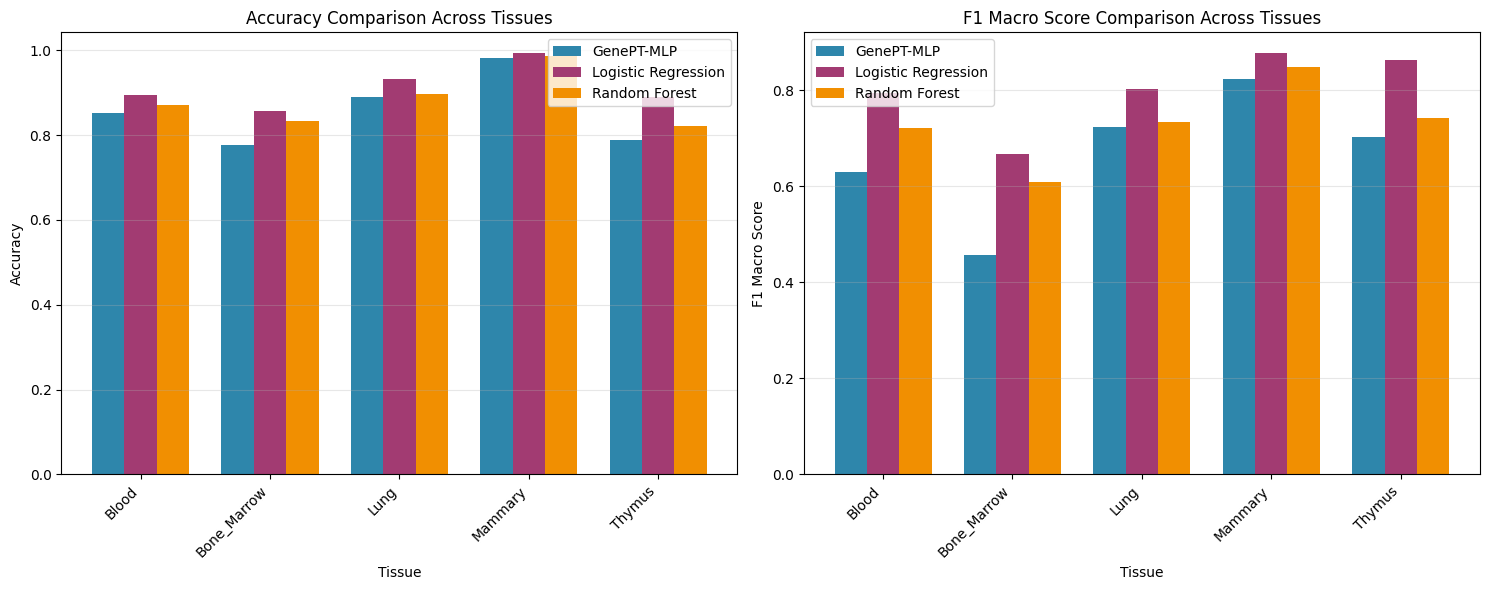


Plot saved to: tabula_sapiens_benchmark_comparison.png


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_tissue_comparison(all_tissue_results: Dict):
    """Create visualization of results across tissues."""
    
    if not all_tissue_results:
        print("No results to plot")
        return
    
    # Prepare data for plotting
    tissues = []
    genept_acc = []
    genept_f1 = []
    lr_acc = []
    lr_f1 = []
    rf_acc = []
    rf_f1 = []
    
    for tissue, results in all_tissue_results.items():
        if results is None:
            continue
        tissues.append(tissue)
        
        # GenePT results
        genept_acc.append(results['genept_results']['accuracy']['mean'])
        genept_f1.append(results['genept_results']['f1_macro']['mean'])
        
        # Baseline results
        if 'Logistic Regression' in results['baseline_results']:
            lr_acc.append(results['baseline_results']['Logistic Regression']['accuracy']['mean'])
            lr_f1.append(results['baseline_results']['Logistic Regression']['f1_macro']['mean'])
        
        if 'Random Forest' in results['baseline_results']:
            rf_acc.append(results['baseline_results']['Random Forest']['accuracy']['mean'])
            rf_f1.append(results['baseline_results']['Random Forest']['f1_macro']['mean'])
    
    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Accuracy comparison
    x = np.arange(len(tissues))
    width = 0.25
    
    axes[0].bar(x - width, genept_acc, width, label='GenePT-MLP', color='#2E86AB')
    if lr_acc:
        axes[0].bar(x, lr_acc, width, label='Logistic Regression', color='#A23B72')
    if rf_acc:
        axes[0].bar(x + width, rf_acc, width, label='Random Forest', color='#F18F01')
    
    axes[0].set_xlabel('Tissue')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Accuracy Comparison Across Tissues')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(tissues, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # F1 Score comparison
    axes[1].bar(x - width, genept_f1, width, label='GenePT-MLP', color='#2E86AB')
    if lr_f1:
        axes[1].bar(x, lr_f1, width, label='Logistic Regression', color='#A23B72')
    if rf_f1:
        axes[1].bar(x + width, rf_f1, width, label='Random Forest', color='#F18F01')
    
    axes[1].set_xlabel('Tissue')
    axes[1].set_ylabel('F1 Macro Score')
    axes[1].set_title('F1 Macro Score Comparison Across Tissues')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(tissues, rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('tabula_sapiens_benchmark_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nPlot saved to: tabula_sapiens_benchmark_comparison.png")

# Create visualization
plot_tissue_comparison(all_tissue_results)

## 10. Hyperparameter Tuning (Optional)

In [59]:
# Load and combine all tissue datasets for hyperparameter tuning
print("Loading all tissue datasets and combining them for hyperparameter search...")
combined_X_list = []
combined_y_list = []
all_cell_types_set = set()
tissue_labels = []
label_offset = 0

for tissue in tissues_to_evaluate:
    print(f"\nLoading {tissue}...")
    try:
        # Load dataset
        adata = load_tabula_sapiens_dataset(tissue)
        
        # Prepare dataset with fresh label encoder for each tissue
        data_processor.label_encoder = LabelEncoder()  # Reset label encoder
        X, y, cell_types = data_processor.prepare_dataset(adata)
        print(f"  Prepared {tissue}: {X.shape[0]} cells, {len(cell_types)} cell types")
        
        # Adjust labels to be globally unique across tissues
        y_adjusted = y + label_offset
        label_offset += len(cell_types)
        
        # Add to combined lists
        combined_X_list.append(X)
        combined_y_list.append(y_adjusted)
        all_cell_types_set.update([(f"{tissue}_{ct}", idx + label_offset - len(cell_types)) 
                                   for idx, ct in enumerate(cell_types)])
        tissue_labels.extend([tissue] * len(X))
        
        # Free memory
        del adata, X, y
        
    except Exception as e:
        print(f"  Error loading {tissue}: {e}")
        continue

# Combine all data
if combined_X_list:
    print("\nCombining all datasets...")
    combined_X = np.vstack(combined_X_list)
    combined_y = np.concatenate(combined_y_list)
    
    # Create a proper mapping of cell types
    all_cell_types = sorted(list(all_cell_types_set), key=lambda x: x[1])
    combined_cell_types = [ct[0] for ct in all_cell_types]
    
    print(f"\nCombined dataset:")
    print(f"  Total samples: {combined_X.shape[0]}")
    print(f"  Feature dimension: {combined_X.shape[1]}")
    print(f"  Total unique cell types across all tissues: {len(combined_cell_types)}")
    print(f"  Tissues included: {len(set(tissue_labels))}")
    
    # Show distribution across tissues
    tissue_counts = pd.Series(tissue_labels).value_counts()
    print(f"\nSamples per tissue:")
    for tissue, count in tissue_counts.items():
        print(f"  {tissue}: {count}")
    
    # Clean up intermediate lists
    del combined_X_list, combined_y_list
    print("\nCombined dataset ready for hyperparameter tuning!")
else:
    print("No datasets could be loaded!")
    combined_X = None
    combined_y = None
    combined_cell_types = None

Loading all tissue datasets and combining them for hyperparameter search...

Loading Blood...
Loading Blood from: /Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark/homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Blood_v2_curated.h5ad
File size: 0.69 GB
Dataset structure:
  - Shape: (17802, 27284)
  - Layers: ['X_original', 'decontXcounts', 'scale_data']
  - X matrix: Present
Loaded Blood: 17802 cells, 27284 genes
Cell types: 19
Data is sparse with 9.17% non-zero elements
Memory usage (sparse): ~0.18 GB
Processing dataset with 17802 cells and 27284 genes
Filtering 3 rare cell types
After filtering: 17788 cells, 16 cell types
Processed feature_name column for gene symbols
Example genes after processing: ['DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH']
Creating embedding matrix for 27284 genes
Selecting embedding inidices
Embedding matrix shape: (500, 18402)
Valid genes matched: 18402 out of 27284
Creating cell embeddings...
  Prepared Blood: 17788 cells, 16 cell types

Loading Bone_Mar

In [63]:
# Grid search for hyperparameters on combined dataset
def hyperparameter_search(X, y, cell_types, dataset_name="combined"):
    """Perform grid search for optimal hyperparameters."""
    
    # Define search space
    param_grid = {
        'learning_rate': [2.5e-4, 5e-4, 7.5e-4],
        'use_adapter': [False, True],
        'freeze_strategy': ['all_but_output', 'last_two_layers']  # Can add 'last_two_layers' but keeping simple for now
    }
    
    best_score = 0
    best_params = None
    all_results = []
    
    # Quick evaluation with fewer epochs and single fold
    quick_config = copy.deepcopy(config)
    quick_config.max_adaptation_epochs = 100  # More epochs for combined dataset
    quick_config.n_folds = 2  # Fewer folds for quick evaluation
    
    for lr in param_grid['learning_rate']:
        for use_adapter in param_grid['use_adapter']:
            for freeze_strategy in param_grid['freeze_strategy']:
                print(f"\nTrying LR={lr}, Adapter={use_adapter}, Freeze={freeze_strategy}")
                
                # Update config
                quick_config.adaptation_lr = lr
                quick_config.use_adapter_layer = use_adapter
                
                # Run quick evaluation
                evaluator_quick = CrossValidationEvaluator(quick_config, base_model)
                results_quick = evaluator_quick.run_cross_validation(
                    X, y, cell_types,
                    dataset_name=f"{dataset_name}_hp_search",
                    use_wandb=False
                )
                
                # Store results
                score = results_quick['f1_macro']['mean']
                param_set = {
                    'learning_rate': lr,
                    'use_adapter': use_adapter,
                    'freeze_strategy': freeze_strategy,
                    'f1_score': score,
                    'accuracy': results_quick['accuracy']['mean']
                }
                all_results.append(param_set)
                
                # Check if better
                if score > best_score:
                    best_score = score
                    best_params = {
                        'learning_rate': lr,
                        'use_adapter': use_adapter,
                        'freeze_strategy': freeze_strategy
                    }
                
                print(f"F1 Score: {score:.4f}, Accuracy: {results_quick['accuracy']['mean']:.4f}")
    
    # Display all results
    results_df = pd.DataFrame(all_results)
    print("\n=== Hyperparameter Search Results ===")
    print(results_df.sort_values('f1_score', ascending=False).to_string(index=False))
    
    print(f"\nBest parameters: {best_params}")
    print(f"Best F1 Score: {best_score:.4f}")
    
    return best_params, results_df

# Run hyperparameter search on combined dataset
if combined_X is not None:
    print("\n" + "="*60)
    print("Starting hyperparameter search on combined dataset")
    print("="*60)
    best_params, hp_results = hyperparameter_search(combined_X, combined_y, combined_cell_types)
    
    # Save hyperparameter search results
    hp_results.to_csv("hyperparameter_search_results.csv", index=False)
    print("\nHyperparameter search results saved to: hyperparameter_search_results.csv")
else:
    print("Combined dataset not available for hyperparameter search")


Starting hyperparameter search on combined dataset

Trying LR=0.00025, Adapter=False, Freeze=all_but_output

=== Fold 1/2 ===
Train: 26388, Val: 6597, Test: 32985
Epoch 0: Train Loss: 3.8803, Val Loss: 3.6259, Val Acc: 0.1969, Val F1: 0.0212
Epoch 1: Train Loss: 2.8679, Val Loss: 2.4812, Val Acc: 0.5078, Val F1: 0.1104
Epoch 2: Train Loss: 2.2481, Val Loss: 1.9972, Val Acc: 0.5783, Val F1: 0.1509
Epoch 3: Train Loss: 1.8828, Val Loss: 1.7184, Val Acc: 0.6121, Val F1: 0.1839
Epoch 4: Train Loss: 1.6709, Val Loss: 1.5559, Val Acc: 0.6377, Val F1: 0.2109
Epoch 5: Train Loss: 1.5405, Val Loss: 1.4567, Val Acc: 0.6523, Val F1: 0.2322
Epoch 6: Train Loss: 1.4627, Val Loss: 1.3960, Val Acc: 0.6626, Val F1: 0.2421
Epoch 7: Train Loss: 1.4165, Val Loss: 1.3640, Val Acc: 0.6668, Val F1: 0.2476
Epoch 8: Train Loss: 1.3862, Val Loss: 1.3440, Val Acc: 0.6691, Val F1: 0.2510
Epoch 9: Train Loss: 1.3743, Val Loss: 1.3357, Val Acc: 0.6711, Val F1: 0.2537
Epoch 10: Train Loss: 1.3639, Val Loss: 1.3287

## 11. Save Results and Generate Report

In [65]:
# Update configuration with best hyperparameters
print("\n" + "="*60)
print("Updating configuration with best hyperparameters")
print("="*60)

# Create optimized configuration based on hyperparameter search
optimized_config = copy.deepcopy(config)
optimized_config.adaptation_lr = 0.00075  # Best learning rate
optimized_config.use_adapter_layer = True  # Use adapter layer
optimized_config.freeze_base_model = True  # Freeze all but output (already set)
optimized_config.max_adaptation_epochs = 100  # More epochs for better training

print("Optimized configuration:")
print(f"  - Learning rate: {optimized_config.adaptation_lr}")
print(f"  - Use adapter layer: {optimized_config.use_adapter_layer}")
print(f"  - Freeze base model: {optimized_config.freeze_base_model}")
print(f"  - Max epochs: {optimized_config.max_adaptation_epochs}")

# Create new evaluator with optimized config
optimized_evaluator = CrossValidationEvaluator(optimized_config, base_model)

# Re-evaluate all tissues with optimized parameters
print("\n" + "="*60)
print("Re-evaluating all tissues with optimized hyperparameters")
print("="*60)

optimized_tissue_results = {}

for tissue in tissues_to_evaluate:
    print(f"\n" + "="*50)
    print(f"Evaluating {tissue} with optimized parameters")
    print("="*50)
    
    try:
        # Load dataset
        adata = load_tabula_sapiens_dataset(tissue)
        
        # Prepare dataset
        print(f"\nPreparing {tissue} dataset...")
        data_processor.label_encoder = LabelEncoder()  # Reset label encoder
        X, y, cell_types = data_processor.prepare_dataset(adata)
        print(f"Prepared: X shape: {X.shape}, y shape: {y.shape}")
        print(f"Number of cell types: {len(cell_types)}")
        
        # Free memory
        del adata
        
        # Run cross-validation with optimized parameters
        print(f"\nRunning optimized cross-validation for {tissue}...")
        results = optimized_evaluator.run_cross_validation(
            X, y, cell_types,
            dataset_name=f"Optimized_TabulaSapiens_{tissue}",
            use_wandb=False  # Set to True for WandB tracking
        )
        
        # Run baseline comparisons for reference
        print(f"\nEvaluating baseline classifiers for {tissue}...")
        baseline_results = evaluate_baseline_classifiers(X, y, cell_types)
        
        # Store complete results
        tissue_results = {
            'tissue': tissue,
            'n_cells': len(X),
            'n_cell_types': len(cell_types),
            'genept_results': results,
            'baseline_results': baseline_results,
            'cell_types': cell_types
        }
        
        optimized_tissue_results[tissue] = tissue_results
        
        # Free memory
        del X, y
        
        print(f"\n{tissue} Results:")
        print(f"  GenePT-MLP (Optimized): Acc={results['accuracy']['mean']:.4f}±{results['accuracy']['std']:.4f}, "
              f"F1={results['f1_macro']['mean']:.4f}±{results['f1_macro']['std']:.4f}")
        print(f"  Logistic Regression: Acc={baseline_results['Logistic Regression']['accuracy']['mean']:.4f}, "
              f"F1={baseline_results['Logistic Regression']['f1_macro']['mean']:.4f}")
        
    except Exception as e:
        print(f"Error evaluating {tissue}: {e}")
        continue

print(f"\n\nOptimized evaluation complete!")
print(f"Successfully evaluated {len(optimized_tissue_results)} tissues")


Updating configuration with best hyperparameters
Optimized configuration:
  - Learning rate: 0.00075
  - Use adapter layer: True
  - Freeze base model: True
  - Max epochs: 100

Re-evaluating all tissues with optimized hyperparameters

Evaluating Blood with optimized parameters
Loading Blood from: /Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark/homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Blood_v2_curated.h5ad
File size: 0.69 GB
Dataset structure:
  - Shape: (17802, 27284)
  - Layers: ['X_original', 'decontXcounts', 'scale_data']
  - X matrix: Present
Loaded Blood: 17802 cells, 27284 genes
Cell types: 19
Data is sparse with 9.17% non-zero elements
Memory usage (sparse): ~0.18 GB

Preparing Blood dataset...
Processing dataset with 17802 cells and 27284 genes
Filtering 3 rare cell types
After filtering: 17788 cells, 16 cell types
Processed feature_name column for gene symbols
Example genes after processing: ['DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH']
Creating embedding matri

In [ ]:
# Create comparison table for optimized results
if optimized_tissue_results:
    print("\n" + "="*60)
    print("Comparison: Original vs Optimized GenePT-MLP")
    print("="*60)
    
    comparison_data = []
    
    for tissue in tissues_to_evaluate:
        if tissue in all_tissue_results and tissue in optimized_tissue_results:
            # Original results
            orig = all_tissue_results[tissue]['genept_results']
            comparison_data.append({
                'Tissue': tissue,
                'Configuration': 'Original',
                'Accuracy': f"{orig['accuracy']['mean']:.4f} ± {orig['accuracy']['std']:.4f}",
                'F1_Macro': f"{orig['f1_macro']['mean']:.4f} ± {orig['f1_macro']['std']:.4f}",
                'Precision': f"{orig['precision_macro']['mean']:.4f} ± {orig['precision_macro']['std']:.4f}",
                'Recall': f"{orig['recall_macro']['mean']:.4f} ± {orig['recall_macro']['std']:.4f}"
            })
            
            # Optimized results
            opt = optimized_tissue_results[tissue]['genept_results']
            comparison_data.append({
                'Tissue': tissue,
                'Configuration': 'Optimized',
                'Accuracy': f"{opt['accuracy']['mean']:.4f} ± {opt['accuracy']['std']:.4f}",
                'F1_Macro': f"{opt['f1_macro']['mean']:.4f} ± {opt['f1_macro']['std']:.4f}",
                'Precision': f"{opt['precision_macro']['mean']:.4f} ± {opt['precision_macro']['std']:.4f}",
                'Recall': f"{opt['recall_macro']['mean']:.4f} ± {opt['recall_macro']['std']:.4f}"
            })
            
            # Best baseline for reference
            lr = all_tissue_results[tissue]['baseline_results']['Logistic Regression']
            comparison_data.append({
                'Tissue': tissue,
                'Configuration': 'Logistic Regression',
                'Accuracy': f"{lr['accuracy']['mean']:.4f} ± {lr['accuracy']['std']:.4f}",
                'F1_Macro': f"{lr['f1_macro']['mean']:.4f} ± {lr['f1_macro']['std']:.4f}",
                'Precision': '-',
                'Recall': '-'
            })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    
    # Save comparison to CSV
    comparison_df.to_csv("optimized_comparison_results.csv", index=False)
    print("\n\nComparison saved to: optimized_comparison_results.csv")
    
    # Calculate improvements
    print("\n" + "="*60)
    print("Performance Improvements with Optimized Parameters")
    print("="*60)
    
    for tissue in tissues_to_evaluate:
        if tissue in all_tissue_results and tissue in optimized_tissue_results:
            orig_acc = all_tissue_results[tissue]['genept_results']['accuracy']['mean']
            orig_f1 = all_tissue_results[tissue]['genept_results']['f1_macro']['mean']
            opt_acc = optimized_tissue_results[tissue]['genept_results']['accuracy']['mean']
            opt_f1 = optimized_tissue_results[tissue]['genept_results']['f1_macro']['mean']
            
            acc_improvement = (opt_acc - orig_acc) * 100
            f1_improvement = (opt_f1 - orig_f1) * 100
            
            print(f"\n{tissue}:")
            print(f"  Accuracy: {orig_acc:.4f} -> {opt_acc:.4f} ({acc_improvement:+.2f}%)")
            print(f"  F1 Score: {orig_f1:.4f} -> {opt_f1:.4f} ({f1_improvement:+.2f}%)")

In [67]:
# Analyze donor information across tissues
print("\n" + "="*60)
print("Analyzing Donor Information Across Tissues")
print("="*60)

donor_stats = []

for tissue in tissues_to_evaluate:
    print(f"\nAnalyzing {tissue}...")
    try:
        # Load dataset
        adata = load_tabula_sapiens_dataset(tissue)
        
        # Check for donor columns
        donor_columns = [col for col in adata.obs.columns if 'donor' in col.lower() or 'sample' in col.lower() or 'patient' in col.lower()]
        print(f"  Potential donor columns found: {donor_columns}")
        
        # Use the most likely donor column
        donor_col = None
        for col in ['donor_id', 'donor', 'sample_id', 'sample', 'patient_id', 'patient']:
            if col in adata.obs.columns:
                donor_col = col
                break
        
        if donor_col:
            print(f"  Using donor column: {donor_col}")
            
            # Get donor statistics
            donor_counts = adata.obs[donor_col].value_counts()
            n_donors = len(donor_counts)
            n_cells = len(adata.obs)
            
            # Calculate statistics
            cells_per_donor_mean = donor_counts.mean()
            cells_per_donor_std = donor_counts.std()
            cells_per_donor_min = donor_counts.min()
            cells_per_donor_max = donor_counts.max()
            cells_per_donor_median = donor_counts.median()
            
            # Store results
            donor_stats.append({
                'Tissue': tissue,
                'Total_Cells': n_cells,
                'Unique_Donors': n_donors,
                'Cells_Per_Donor_Mean': f"{cells_per_donor_mean:.1f}",
                'Cells_Per_Donor_Std': f"{cells_per_donor_std:.1f}",
                'Cells_Per_Donor_Median': f"{cells_per_donor_median:.0f}",
                'Cells_Per_Donor_Min': cells_per_donor_min,
                'Cells_Per_Donor_Max': cells_per_donor_max,
                'Donor_Column': donor_col
            })
            
            # Show top donors by cell count
            print(f"\n  Top 5 donors by cell count in {tissue}:")
            for donor, count in donor_counts.head(5).items():
                print(f"    {donor}: {count} cells ({count/n_cells*100:.1f}%)")
            
        else:
            print(f"  WARNING: No donor column found in {tissue}")
            # Check all columns to help debug
            print(f"  Available columns: {list(adata.obs.columns)[:20]}")
            
            donor_stats.append({
                'Tissue': tissue,
                'Total_Cells': len(adata.obs),
                'Unique_Donors': 'Unknown',
                'Cells_Per_Donor_Mean': '-',
                'Cells_Per_Donor_Std': '-',
                'Cells_Per_Donor_Median': '-',
                'Cells_Per_Donor_Min': '-',
                'Cells_Per_Donor_Max': '-',
                'Donor_Column': 'Not Found'
            })
        
        # Clean up
        del adata
        
    except Exception as e:
        print(f"  Error analyzing {tissue}: {e}")
        donor_stats.append({
            'Tissue': tissue,
            'Total_Cells': 'Error',
            'Unique_Donors': 'Error',
            'Cells_Per_Donor_Mean': '-',
            'Cells_Per_Donor_Std': '-',
            'Cells_Per_Donor_Median': '-',
            'Cells_Per_Donor_Min': '-',
            'Cells_Per_Donor_Max': '-',
            'Donor_Column': 'Error'
        })

# Create summary table
donor_df = pd.DataFrame(donor_stats)
print("\n" + "="*60)
print("Donor Statistics Summary Table")
print("="*60)
print(donor_df.to_string(index=False))

# Save to CSV
donor_df.to_csv("donor_statistics.csv", index=False)
print("\n\nDonor statistics saved to: donor_statistics.csv")

# Calculate overall statistics if we have donor information
tissues_with_donors = [row for row in donor_stats if row['Unique_Donors'] != 'Unknown' and row['Unique_Donors'] != 'Error']
if tissues_with_donors:
    print("\n" + "="*60)
    print("Overall Donor Distribution Analysis")
    print("="*60)
    
    total_cells = sum(row['Total_Cells'] for row in tissues_with_donors)
    total_donors = sum(row['Unique_Donors'] for row in tissues_with_donors if isinstance(row['Unique_Donors'], int))
    
    print(f"\nTotal cells across tissues with donor info: {total_cells:,}")
    print(f"Total unique donors across tissues: {total_donors}")
    print(f"Average cells per donor (overall): {total_cells/total_donors:.1f}")
    
    print("\n\nIMPORTANT: Donor leakage analysis")
    print("-" * 40)
    print("If the same donors appear in both training and test sets during cross-validation,")
    print("the model may learn donor-specific patterns rather than generalizable cell type patterns.")
    print("This could lead to inflated performance metrics.")
    print("\nNext step: Implement donor-aware cross-validation to ensure donors are not split across folds.")


Analyzing Donor Information Across Tissues

Analyzing Blood...
Loading Blood from: /Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark/homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Blood_v2_curated.h5ad
File size: 0.69 GB
Dataset structure:
  - Shape: (17802, 27284)
  - Layers: ['X_original', 'decontXcounts', 'scale_data']
  - X matrix: Present
Loaded Blood: 17802 cells, 27284 genes
Cell types: 19
Data is sparse with 9.17% non-zero elements
Memory usage (sparse): ~0.18 GB
  Potential donor columns found: ['donor_id', 'sample_id', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'scvi_leiden_donorassay_full', 'sample_number']
  Using donor column: donor_id

  Top 5 donors by cell count in Blood:
    TSP21: 14103 cells (79.2%)
    TSP25: 3202 cells (18.0%)
    TSP27: 497 cells (2.8%)

Analyzing Bone_Marrow...
Loading Bone_Marrow from: /Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark/homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Bone_Marrow_v2_curated

In [ ]:
# Visualize donor distribution
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_donor_distribution(donor_df):
    """Create visualizations of donor distribution across tissues."""
    
    # Filter out tissues without donor information
    valid_data = donor_df[donor_df['Unique_Donors'] != 'Unknown'].copy()
    
    if valid_data.empty:
        print("No valid donor data to visualize")
        return
    
    # Convert string numbers back to numeric for plotting
    for col in ['Unique_Donors', 'Cells_Per_Donor_Min', 'Cells_Per_Donor_Max']:
        if col in valid_data.columns:
            valid_data[col] = pd.to_numeric(valid_data[col], errors='coerce')
    
    valid_data['Cells_Per_Donor_Mean'] = valid_data['Cells_Per_Donor_Mean'].str.replace(',', '').astype(float)
    valid_data['Cells_Per_Donor_Median'] = valid_data['Cells_Per_Donor_Median'].str.replace(',', '').astype(float)
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Number of donors per tissue
    axes[0, 0].bar(valid_data['Tissue'], valid_data['Unique_Donors'], color='#2E86AB')
    axes[0, 0].set_xlabel('Tissue')
    axes[0, 0].set_ylabel('Number of Unique Donors')
    axes[0, 0].set_title('Unique Donors per Tissue')
    axes[0, 0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(valid_data['Unique_Donors']):
        axes[0, 0].text(i, v + 0.5, str(int(v)), ha='center')
    
    # 2. Average cells per donor
    axes[0, 1].bar(valid_data['Tissue'], valid_data['Cells_Per_Donor_Mean'], color='#A23B72')
    axes[0, 1].set_xlabel('Tissue')
    axes[0, 1].set_ylabel('Average Cells per Donor')
    axes[0, 1].set_title('Mean Cells per Donor by Tissue')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Cell distribution range (min to max per donor)
    tissues = valid_data['Tissue'].tolist()
    x_pos = np.arange(len(tissues))
    
    # Plot ranges
    for i, tissue in enumerate(tissues):
        row = valid_data[valid_data['Tissue'] == tissue].iloc[0]
        min_cells = row['Cells_Per_Donor_Min']
        max_cells = row['Cells_Per_Donor_Max']
        median_cells = row['Cells_Per_Donor_Median']
        
        axes[1, 0].plot([i, i], [min_cells, max_cells], 'k-', linewidth=1)
        axes[1, 0].plot(i, min_cells, 'v', color='red', markersize=8, label='Min' if i == 0 else '')
        axes[1, 0].plot(i, max_cells, '^', color='green', markersize=8, label='Max' if i == 0 else '')
        axes[1, 0].plot(i, median_cells, 'o', color='blue', markersize=8, label='Median' if i == 0 else '')
    
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels(tissues, rotation=45, ha='right')
    axes[1, 0].set_ylabel('Cells per Donor')
    axes[1, 0].set_title('Cell Count Range per Donor')
    axes[1, 0].legend()
    axes[1, 0].set_yscale('log')  # Log scale for better visualization
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Total cells vs number of donors (scatter plot)
    axes[1, 1].scatter(valid_data['Unique_Donors'], valid_data['Total_Cells'], s=100, color='#F18F01')
    for idx, row in valid_data.iterrows():
        axes[1, 1].annotate(row['Tissue'], 
                            (row['Unique_Donors'], row['Total_Cells']),
                            xytext=(5, 5), textcoords='offset points', fontsize=9)
    axes[1, 1].set_xlabel('Number of Unique Donors')
    axes[1, 1].set_ylabel('Total Cells')
    axes[1, 1].set_title('Total Cells vs Number of Donors')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('donor_distribution_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nVisualization saved to: donor_distribution_analysis.png")

# Create visualization if we have donor data
if donor_df is not None and not donor_df.empty:
    visualize_donor_distribution(donor_df)
    
    # Calculate additional statistics
    print("\n" + "="*60)
    print("Donor Distribution Insights")
    print("="*60)
    
    valid_tissues = donor_df[donor_df['Unique_Donors'] != 'Unknown']
    if not valid_tissues.empty:
        for _, row in valid_tissues.iterrows():
            if isinstance(row['Unique_Donors'], (int, float)):
                avg_cells = float(row['Cells_Per_Donor_Mean'].replace(',', ''))
                print(f"\n{row['Tissue']}:")
                print(f"  - {row['Unique_Donors']} donors with {row['Total_Cells']} total cells")
                print(f"  - Average {avg_cells:.0f} cells/donor")
                print(f"  - Range: {row['Cells_Per_Donor_Min']} to {row['Cells_Per_Donor_Max']} cells/donor")
                
                # Calculate imbalance ratio
                if row['Cells_Per_Donor_Min'] > 0:
                    imbalance_ratio = row['Cells_Per_Donor_Max'] / row['Cells_Per_Donor_Min']
                    print(f"  - Imbalance ratio (max/min): {imbalance_ratio:.1f}x")

In [81]:
# Define DonorAwareCrossValidationEvaluator class and baseline evaluators
print("\n" + "="*60)
print("SETTING UP DONOR-AWARE CROSS-VALIDATION & BASELINES")
print("="*60)

from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Tissues with 3 donors based on our analysis
tissues_with_3_donors = ["Blood", "Bone_Marrow", "Thymus"]

class DonorAwareCrossValidationEvaluator(CrossValidationEvaluator):
    """Modified evaluator that uses GroupKFold to prevent donor leakage."""
    
    def run_donor_aware_cross_validation(
        self,
        X: np.ndarray,
        y: np.ndarray,
        donor_ids: np.ndarray,
        cell_types: List[str],
        dataset_name: str,
        use_wandb: bool = False
    ) -> Dict:
        """Execute donor-aware cross-validation using GroupKFold."""
        
        print(f"\nRunning DONOR-AWARE cross-validation for {dataset_name}")
        print(f"Unique donors: {np.unique(donor_ids)}")
        print(f"Cells per donor: {pd.Series(donor_ids).value_counts().to_dict()}")
        
        # Initialize main WandB run for summary if needed
        if use_wandb:
            main_run = wandb.init(
                project=self.config.wandb_project,
                name=f"donor_aware_{dataset_name}",
                config={
                    "base_model_run": self.config.base_wandb_run,
                    "dataset": dataset_name,
                    "n_donors": len(np.unique(donor_ids)),
                    "n_samples": len(X),
                    "n_classes": len(cell_types),
                    "validation_type": "donor_aware",
                    "config": self.config.__dict__
                },
                reinit=True
            )
        
        # Setup GroupKFold with 3 splits (one donor held out each time)
        gkf = GroupKFold(n_splits=3)
        
        fold_results = []
        
        for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=donor_ids)):
            # Identify which donor is in test set
            test_donor = np.unique(donor_ids[test_idx])[0]
            train_donors = np.unique(donor_ids[train_idx])
            
            print(f"\n=== Fold {fold_idx + 1}/3 ===")
            print(f"Test donor: {test_donor}, Train donors: {train_donors}")
            
            # Split data
            X_train_full, X_test = X[train_idx], X[test_idx]
            y_train_full, y_test = y[train_idx], y[test_idx]
            
            # Create validation split from training data (from different donor)
            # Use stratified split within training data
            train_idx_inner, val_idx_inner = train_test_split(
                np.arange(len(X_train_full)),
                test_size=self.config.validation_split,
                stratify=y_train_full,
                random_state=self.config.random_seed + fold_idx
            )
            
            X_train = X_train_full[train_idx_inner]
            X_val = X_train_full[val_idx_inner]
            y_train = y_train_full[train_idx_inner]
            y_val = y_train_full[val_idx_inner]
            
            print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
            
            # Adapt model for this fold
            adapted_model = self.adapter.create_adapted_model(
                self.base_model,
                num_target_classes=len(cell_types),
                config=self.config
            )
            
            # Train on fold
            trained_model, val_metrics = self.trainer.train_fold(
                adapted_model,
                X_train, y_train,
                X_val, y_val,
                fold_idx,
                f"{dataset_name}_donor_{test_donor}",
                use_wandb=use_wandb
            )
            
            # Evaluate on test fold
            test_dataset = TensorDataset(
                torch.FloatTensor(X_test),
                torch.LongTensor(y_test)
            )
            test_loader = DataLoader(
                test_dataset,
                batch_size=self.config.batch_size,
                shuffle=False
            )
            
            test_metrics = self.trainer.evaluate(
                trained_model,
                test_loader,
                nn.CrossEntropyLoss()
            )
            
            # Store results with donor information
            fold_result = {
                'fold': fold_idx,
                'test_donor': test_donor,
                'val_metrics': val_metrics,
                'test_metrics': test_metrics
            }
            fold_results.append(fold_result)
            
            print(f"Test Metrics - Acc: {test_metrics['accuracy']:.4f}, "
                  f"F1: {test_metrics['f1_macro']:.4f}")
        
        # Aggregate results
        final_metrics = self.aggregate_metrics(fold_results)
        
        # Log summary to WandB
        if use_wandb:
            wandb.log({
                "final_accuracy_mean": final_metrics['accuracy']['mean'],
                "final_accuracy_std": final_metrics['accuracy']['std'],
                "final_f1_macro_mean": final_metrics['f1_macro']['mean'],
                "final_f1_macro_std": final_metrics['f1_macro']['std'],
                "validation_type": "donor_aware"
            })
            wandb.finish()
        
        return final_metrics

def evaluate_logistic_regression_standard(
    X: np.ndarray,
    y: np.ndarray,
    cell_types: List[str],
    dataset_name: str,
    n_folds: int = 5
) -> Dict:
    """Evaluate Logistic Regression with standard random CV (has donor leakage)."""
    
    print(f"\nRunning Logistic Regression with STANDARD CV for {dataset_name}")
    
    # Setup standard StratifiedKFold
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    fold_results = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f"Fold {fold_idx + 1}/{n_folds}")
        
        # Split data
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Scale features for Logistic Regression
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train Logistic Regression
        lr_model = LogisticRegression(max_iter=1000, multi_class='ovr', random_state=42)
        lr_model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = lr_model.predict(X_test_scaled)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        
        fold_results.append({
            'accuracy': accuracy,
            'f1_macro': f1,
            'precision_macro': precision,
            'recall_macro': recall
        })
        
        print(f"  Acc: {accuracy:.4f}, F1: {f1:.4f}")
    
    # Aggregate results
    final_metrics = {}
    for metric in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']:
        values = [r[metric] for r in fold_results]
        final_metrics[metric] = {
            'mean': np.mean(values),
            'std': np.std(values),
            'per_fold': values
        }
    
    return final_metrics

def evaluate_logistic_regression_donor_aware(
    X: np.ndarray,
    y: np.ndarray,
    donor_ids: np.ndarray,
    cell_types: List[str],
    dataset_name: str
) -> Dict:
    """Evaluate Logistic Regression on GenePT embeddings with donor-aware CV."""
    
    print(f"\nRunning Logistic Regression with DONOR-AWARE CV for {dataset_name}")
    
    # Setup GroupKFold with 3 splits
    gkf = GroupKFold(n_splits=3)
    
    fold_results = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=donor_ids)):
        test_donor = np.unique(donor_ids[test_idx])[0]
        
        print(f"Fold {fold_idx + 1}: Test donor {test_donor}")
        
        # Split data
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Scale features for Logistic Regression
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train Logistic Regression
        lr_model = LogisticRegression(max_iter=1000, multi_class='ovr', random_state=42)
        lr_model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = lr_model.predict(X_test_scaled)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        
        fold_results.append({
            'accuracy': accuracy,
            'f1_macro': f1,
            'precision_macro': precision,
            'recall_macro': recall
        })
        
        print(f"  Acc: {accuracy:.4f}, F1: {f1:.4f}")
    
    # Aggregate results
    final_metrics = {}
    for metric in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']:
        values = [r[metric] for r in fold_results]
        final_metrics[metric] = {
            'mean': np.mean(values),
            'std': np.std(values),
            'per_fold': values
        }
    
    return final_metrics

def evaluate_zero_shot(
    base_model: MLPClassifier,
    X: np.ndarray,
    y: np.ndarray,
    donor_ids: np.ndarray,
    cell_types: List[str],
    dataset_name: str,
    config: AdaptationConfig
) -> Dict:
    """Evaluate base model without fine-tuning (zero-shot) with donor-aware splits."""
    
    print(f"\nRunning ZERO-SHOT evaluation (no fine-tuning) for {dataset_name}")
    
    # The base model expects 377 classes (original CellXGene training)
    # We need to map our local cell types to the original classes if possible
    # For now, we'll just evaluate on matching dimensions or skip if incompatible
    
    if len(cell_types) > base_model.num_classes:
        print(f"WARNING: Dataset has {len(cell_types)} cell types but base model expects {base_model.num_classes}")
        print("Cannot perform zero-shot evaluation - incompatible dimensions")
        return None
    
    # Setup GroupKFold with 3 splits
    gkf = GroupKFold(n_splits=3)
    
    fold_results = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=donor_ids)):
        test_donor = np.unique(donor_ids[test_idx])[0]
        
        print(f"Fold {fold_idx + 1}: Test donor {test_donor}")
        
        # Get test data only (no training needed for zero-shot)
        X_test = X[test_idx]
        y_test = y[test_idx]
        
        # Create test loader
        test_dataset = TensorDataset(
            torch.FloatTensor(X_test),
            torch.LongTensor(y_test)
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=config.batch_size,
            shuffle=False
        )
        
        # Evaluate base model directly
        base_model.eval()
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X = batch_X.to(config.device)
                batch_y = batch_y.to(config.device)
                
                outputs = base_model(batch_X)
                # Only use predictions for classes that exist in our dataset
                outputs = outputs[:, :len(cell_types)]
                
                preds = outputs.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(batch_y.cpu().numpy())
        
        # Calculate metrics
        accuracy = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        
        fold_results.append({
            'accuracy': accuracy,
            'f1_macro': f1,
            'precision_macro': precision,
            'recall_macro': recall
        })
        
        print(f"  Acc: {accuracy:.4f}, F1: {f1:.4f}")
    
    # Aggregate results
    final_metrics = {}
    for metric in ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']:
        values = [r[metric] for r in fold_results]
        final_metrics[metric] = {
            'mean': np.mean(values),
            'std': np.std(values),
            'per_fold': values
        }
    
    return final_metrics

# Check if optimized_config exists, if not use the default config
if 'optimized_config' not in globals():
    print("\nWARNING: optimized_config not found, using default config")
    print("You may want to re-run the cells that create optimized_config for best results")
    optimized_config = config  # Fall back to default config

# Initialize donor-aware evaluator with optimized config
donor_aware_evaluator = DonorAwareCrossValidationEvaluator(optimized_config, base_model)

print("\nEvaluators initialized:")
print("  - Donor-aware MLP evaluator")
print("  - Logistic Regression evaluators (both standard and donor-aware)")
print("  - Zero-shot (no fine-tuning) evaluator")
print("\nReady to run comprehensive comparison!")


SETTING UP DONOR-AWARE CROSS-VALIDATION & BASELINES

Evaluators initialized:
  - Donor-aware MLP evaluator
  - Logistic Regression evaluators (both standard and donor-aware)
  - Zero-shot (no fine-tuning) evaluator

Ready to run comprehensive comparison!


In [ ]:
# # Define DonorAwareCrossValidationEvaluator class
# print("\n" + "="*60)
# print("SETTING UP DONOR-AWARE CROSS-VALIDATION")
# print("="*60)

# from sklearn.model_selection import GroupKFold
# import numpy as np
# import pandas as pd

# # Tissues with 3 donors based on our analysis
# tissues_with_3_donors = ["Blood", "Bone_Marrow", "Thymus"]

# class DonorAwareCrossValidationEvaluator(CrossValidationEvaluator):
#     """Modified evaluator that uses GroupKFold to prevent donor leakage."""
    
#     def run_donor_aware_cross_validation(
#         self,
#         X: np.ndarray,
#         y: np.ndarray,
#         donor_ids: np.ndarray,
#         cell_types: List[str],
#         dataset_name: str,
#         use_wandb: bool = False
#     ) -> Dict:
#         """Execute donor-aware cross-validation using GroupKFold."""
        
#         print(f"\nRunning DONOR-AWARE cross-validation for {dataset_name}")
#         print(f"Unique donors: {np.unique(donor_ids)}")
#         print(f"Cells per donor: {pd.Series(donor_ids).value_counts().to_dict()}")
        
#         # Initialize main WandB run for summary if needed
#         if use_wandb:
#             main_run = wandb.init(
#                 project=self.config.wandb_project,
#                 name=f"donor_aware_{dataset_name}",
#                 config={
#                     "base_model_run": self.config.base_wandb_run,
#                     "dataset": dataset_name,
#                     "n_donors": len(np.unique(donor_ids)),
#                     "n_samples": len(X),
#                     "n_classes": len(cell_types),
#                     "validation_type": "donor_aware",
#                     "config": self.config.__dict__
#                 },
#                 reinit=True
#             )
        
#         # Setup GroupKFold with 3 splits (one donor held out each time)
#         gkf = GroupKFold(n_splits=3)
        
#         fold_results = []
        
#         for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=donor_ids)):
#             # Identify which donor is in test set
#             test_donor = np.unique(donor_ids[test_idx])[0]
#             train_donors = np.unique(donor_ids[train_idx])
            
#             print(f"\n=== Fold {fold_idx + 1}/3 ===")
#             print(f"Test donor: {test_donor}, Train donors: {train_donors}")
            
#             # Split data
#             X_train_full, X_test = X[train_idx], X[test_idx]
#             y_train_full, y_test = y[train_idx], y[test_idx]
            
#             # Create validation split from training data (from different donor)
#             # Use stratified split within training data
#             train_idx_inner, val_idx_inner = train_test_split(
#                 np.arange(len(X_train_full)),
#                 test_size=self.config.validation_split,
#                 stratify=y_train_full,
#                 random_state=self.config.random_seed + fold_idx
#             )
            
#             X_train = X_train_full[train_idx_inner]
#             X_val = X_train_full[val_idx_inner]
#             y_train = y_train_full[train_idx_inner]
#             y_val = y_train_full[val_idx_inner]
            
#             print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
            
#             # Adapt model for this fold
#             adapted_model = self.adapter.create_adapted_model(
#                 self.base_model,
#                 num_target_classes=len(cell_types),
#                 config=self.config
#             )
            
#             # Train on fold
#             trained_model, val_metrics = self.trainer.train_fold(
#                 adapted_model,
#                 X_train, y_train,
#                 X_val, y_val,
#                 fold_idx,
#                 f"{dataset_name}_donor_{test_donor}",
#                 use_wandb=use_wandb
#             )
            
#             # Evaluate on test fold
#             test_dataset = TensorDataset(
#                 torch.FloatTensor(X_test),
#                 torch.LongTensor(y_test)
#             )
#             test_loader = DataLoader(
#                 test_dataset,
#                 batch_size=self.config.batch_size,
#                 shuffle=False
#             )
            
#             test_metrics = self.trainer.evaluate(
#                 trained_model,
#                 test_loader,
#                 nn.CrossEntropyLoss()
#             )
            
#             # Store results with donor information
#             fold_result = {
#                 'fold': fold_idx,
#                 'test_donor': test_donor,
#                 'val_metrics': val_metrics,
#                 'test_metrics': test_metrics
#             }
#             fold_results.append(fold_result)
            
#             print(f"Test Metrics - Acc: {test_metrics['accuracy']:.4f}, "
#                   f"F1: {test_metrics['f1_macro']:.4f}")
        
#         # Aggregate results
#         final_metrics = self.aggregate_metrics(fold_results)
        
#         # Log summary to WandB
#         if use_wandb:
#             wandb.log({
#                 "final_accuracy_mean": final_metrics['accuracy']['mean'],
#                 "final_accuracy_std": final_metrics['accuracy']['std'],
#                 "final_f1_macro_mean": final_metrics['f1_macro']['mean'],
#                 "final_f1_macro_std": final_metrics['f1_macro']['std'],
#                 "validation_type": "donor_aware"
#             })
#             wandb.finish()
        
#         return final_metrics

# # Check if optimized_config exists, if not use the default config
# if 'optimized_config' not in globals():
#     print("\nWARNING: optimized_config not found, using default config")
#     print("You may want to re-run the cells that create optimized_config for best results")
#     optimized_config = config  # Fall back to default config

# # Initialize donor-aware evaluator with optimized config
# donor_aware_evaluator = DonorAwareCrossValidationEvaluator(optimized_config, base_model)

# print("\nDonor-aware evaluator initialized with configuration:")
# print(f"  - Learning rate: {optimized_config.adaptation_lr}")
# print(f"  - Use adapter: {optimized_config.use_adapter_layer}")
# print(f"  - Max epochs: {optimized_config.max_adaptation_epochs}")
# print("\nReady to run donor-aware cross-validation!")


SETTING UP DONOR-AWARE CROSS-VALIDATION

Donor-aware evaluator initialized with configuration:
  - Learning rate: 0.00075
  - Use adapter: True
  - Max epochs: 100

Ready to run donor-aware cross-validation!


In [82]:
# Comprehensive comparison: Standard vs Donor-aware CV with multiple methods
print("\n" + "="*60)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*60)

comprehensive_results = {}

for tissue in tissues_with_3_donors:
    print(f"\n" + "="*50)
    print(f"Processing {tissue}")
    print("="*50)
    
    try:
        # Load dataset
        adata = load_tabula_sapiens_dataset(tissue)
        
        # Get donor IDs before filtering
        all_donor_ids = adata.obs['donor_id'].values.copy()
        unique_donors = np.unique(all_donor_ids)
        
        print(f"\nDonors in {tissue}: {unique_donors}")
        print(f"Original donor distribution:")
        for donor in unique_donors:
            n_cells = (all_donor_ids == donor).sum()
            print(f"  {donor}: {n_cells} cells ({n_cells/len(all_donor_ids)*100:.1f}%)")
        
        # Prepare dataset (this may filter cells)
        print(f"\nPreparing {tissue} dataset...")
        data_processor.label_encoder = LabelEncoder()  # Reset label encoder
        X, y, cell_types = data_processor.prepare_dataset(adata)
        print(f"Prepared: X shape: {X.shape}, y shape: {y.shape}")
        print(f"Number of cell types: {len(cell_types)}")
        
        # Get donor IDs for the filtered cells using the stored indices
        if data_processor.filtered_indices is not None:
            donor_ids = all_donor_ids[data_processor.filtered_indices]
        else:
            donor_ids = all_donor_ids
        
        # Verify the lengths match
        if len(donor_ids) != len(X):
            print(f"ERROR: Length mismatch - X: {len(X)}, donor_ids: {len(donor_ids)}")
            continue
        
        print(f"\nFiltered donor distribution:")
        for donor in unique_donors:
            n_cells = (donor_ids == donor).sum()
            if n_cells > 0:
                print(f"  {donor}: {n_cells} cells ({n_cells/len(donor_ids)*100:.1f}%)")
        
        # Store results for this tissue
        tissue_results = {
            'n_cells': len(X),
            'n_cell_types': len(cell_types),
            'n_donors': len(unique_donors),
            'donors': unique_donors.tolist()
        }
        
        # 1. STANDARD MLP (with donor leakage)
        print(f"\n{'='*40}")
        print(f"1. STANDARD MLP (Random CV with leakage)")
        print(f"{'='*40}")
        
        standard_mlp_results = optimized_evaluator.run_cross_validation(
            X, y, cell_types,
            dataset_name=f"Standard_MLP_{tissue}",
            use_wandb=False
        )
        tissue_results['standard_mlp'] = standard_mlp_results
        
        # 2. DONOR-AWARE MLP (no leakage)
        print(f"\n{'='*40}")
        print(f"2. DONOR-AWARE MLP (GroupKFold)")
        print(f"{'='*40}")
        
        donor_aware_mlp_results = donor_aware_evaluator.run_donor_aware_cross_validation(
            X, y, donor_ids, cell_types,
            dataset_name=f"DonorAware_MLP_{tissue}",
            use_wandb=False
        )
        tissue_results['donor_aware_mlp'] = donor_aware_mlp_results
        
        # 3. STANDARD LOGISTIC REGRESSION (with leakage)
        print(f"\n{'='*40}")
        print(f"3. STANDARD LOGISTIC REGRESSION (with leakage)")
        print(f"{'='*40}")
        
        standard_lr_results = evaluate_logistic_regression_standard(
            X, y, cell_types,
            dataset_name=f"Standard_LR_{tissue}"
        )
        tissue_results['standard_lr'] = standard_lr_results
        
        # 4. DONOR-AWARE LOGISTIC REGRESSION (no leakage)
        print(f"\n{'='*40}")
        print(f"4. DONOR-AWARE LOGISTIC REGRESSION")
        print(f"{'='*40}")
        
        donor_aware_lr_results = evaluate_logistic_regression_donor_aware(
            X, y, donor_ids, cell_types,
            dataset_name=f"DonorAware_LR_{tissue}"
        )
        tissue_results['donor_aware_lr'] = donor_aware_lr_results
        
        # 5. ZERO-SHOT (no fine-tuning)
        print(f"\n{'='*40}")
        print(f"5. ZERO-SHOT MLP (No fine-tuning)")
        print(f"{'='*40}")
        
        zero_shot_results = evaluate_zero_shot(
            base_model, X, y, donor_ids, cell_types,
            dataset_name=f"ZeroShot_{tissue}",
            config=optimized_config
        )
        tissue_results['zero_shot'] = zero_shot_results
        
        # Store all results
        comprehensive_results[tissue] = tissue_results
        
        # Print summary table for this tissue
        print(f"\n{'='*60}")
        print(f"SUMMARY for {tissue}")
        print(f"{'='*60}")
        print(f"\n{'Method':<35} | {'Accuracy':^16} | {'F1 Score':^16} | {'Leakage?':^8}")
        print(f"{'-'*35}-+-{'-'*16}-+-{'-'*16}-+-{'-'*8}")
        
        # MLP results
        print(f"{'MLP (standard CV)':<35} | {standard_mlp_results['accuracy']['mean']:7.4f} ± {standard_mlp_results['accuracy']['std']:.4f} | {standard_mlp_results['f1_macro']['mean']:7.4f} ± {standard_mlp_results['f1_macro']['std']:.4f} | {'YES':^8}")
        print(f"{'MLP (donor-aware CV)':<35} | {donor_aware_mlp_results['accuracy']['mean']:7.4f} ± {donor_aware_mlp_results['accuracy']['std']:.4f} | {donor_aware_mlp_results['f1_macro']['mean']:7.4f} ± {donor_aware_mlp_results['f1_macro']['std']:.4f} | {'NO':^8}")
        
        # LR results
        print(f"{'Logistic Regression (standard CV)':<35} | {standard_lr_results['accuracy']['mean']:7.4f} ± {standard_lr_results['accuracy']['std']:.4f} | {standard_lr_results['f1_macro']['mean']:7.4f} ± {standard_lr_results['f1_macro']['std']:.4f} | {'YES':^8}")
        print(f"{'Logistic Regression (donor-aware)':<35} | {donor_aware_lr_results['accuracy']['mean']:7.4f} ± {donor_aware_lr_results['accuracy']['std']:.4f} | {donor_aware_lr_results['f1_macro']['mean']:7.4f} ± {donor_aware_lr_results['f1_macro']['std']:.4f} | {'NO':^8}")
        
        # Zero-shot
        if zero_shot_results:
            print(f"{'Zero-shot (no fine-tuning)':<35} | {zero_shot_results['accuracy']['mean']:7.4f} ± {zero_shot_results['accuracy']['std']:.4f} | {zero_shot_results['f1_macro']['mean']:7.4f} ± {zero_shot_results['f1_macro']['std']:.4f} | {'NO':^8}")
        else:
            print(f"{'Zero-shot (no fine-tuning)':<35} | {'N/A':^16} | {'N/A':^16} | {'N/A':^8}")
        
        # Calculate donor leakage impacts
        print(f"\n🔴 DONOR LEAKAGE IMPACT:")
        mlp_acc_inflation = (standard_mlp_results['accuracy']['mean'] - donor_aware_mlp_results['accuracy']['mean']) * 100
        mlp_f1_inflation = (standard_mlp_results['f1_macro']['mean'] - donor_aware_mlp_results['f1_macro']['mean']) * 100
        lr_acc_inflation = (standard_lr_results['accuracy']['mean'] - donor_aware_lr_results['accuracy']['mean']) * 100
        lr_f1_inflation = (standard_lr_results['f1_macro']['mean'] - donor_aware_lr_results['f1_macro']['mean']) * 100
        
        print(f"   MLP accuracy inflation: {mlp_acc_inflation:+.2f} percentage points")
        print(f"   MLP F1 score inflation: {mlp_f1_inflation:+.2f} percentage points")
        print(f"   LR accuracy inflation:  {lr_acc_inflation:+.2f} percentage points")
        print(f"   LR F1 score inflation:  {lr_f1_inflation:+.2f} percentage points")
        
        # Clean up
        del adata, X, y
        
    except Exception as e:
        print(f"Error processing {tissue}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n\n" + "="*60)
print(f"Completed comprehensive comparison for {len(comprehensive_results)} tissues")
print("="*60)


COMPREHENSIVE MODEL COMPARISON

Processing Blood
Loading Blood from: /Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark/homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Blood_v2_curated.h5ad
File size: 0.69 GB
Dataset structure:
  - Shape: (17802, 27284)
  - Layers: ['X_original', 'decontXcounts', 'scale_data']
  - X matrix: Present
Loaded Blood: 17802 cells, 27284 genes
Cell types: 19
Data is sparse with 9.17% non-zero elements
Memory usage (sparse): ~0.18 GB

Donors in Blood: ['TSP21' 'TSP25' 'TSP27']
Original donor distribution:
  TSP21: 14103 cells (79.2%)
  TSP25: 3202 cells (18.0%)
  TSP27: 497 cells (2.8%)

Preparing Blood dataset...
Processing dataset with 17802 cells and 27284 genes
Filtering 3 rare cell types
After filtering: 17788 cells, 16 cell types
Processed feature_name column for gene symbols
Example genes after processing: ['DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH']
Creating embedding matrix for 27284 genes
Selecting embedding inidices
Embedding matrix shape: (50


DONOR LEAKAGE IMPACT SUMMARY

Comparison Table:
     Tissue  N_Cells  N_Cell_Types  N_Donors    Standard_Acc  DonorAware_Acc Acc_Inflation     Standard_F1   DonorAware_F1 F1_Inflation
      Blood    17788            16         3 0.8818 ± 0.0026 0.7509 ± 0.1348       +13.09% 0.7445 ± 0.0067 0.4505 ± 0.0209      +29.39%
Bone_Marrow     8031            20         3 0.8166 ± 0.0286 0.6959 ± 0.0872       +12.07% 0.5101 ± 0.0525 0.4077 ± 0.0568      +10.25%
     Thymus     9912            22         3 0.8411 ± 0.0079 0.7700 ± 0.1310        +7.11% 0.7862 ± 0.0151 0.6672 ± 0.0906      +11.90%


Results saved to: donor_leakage_comparison.csv


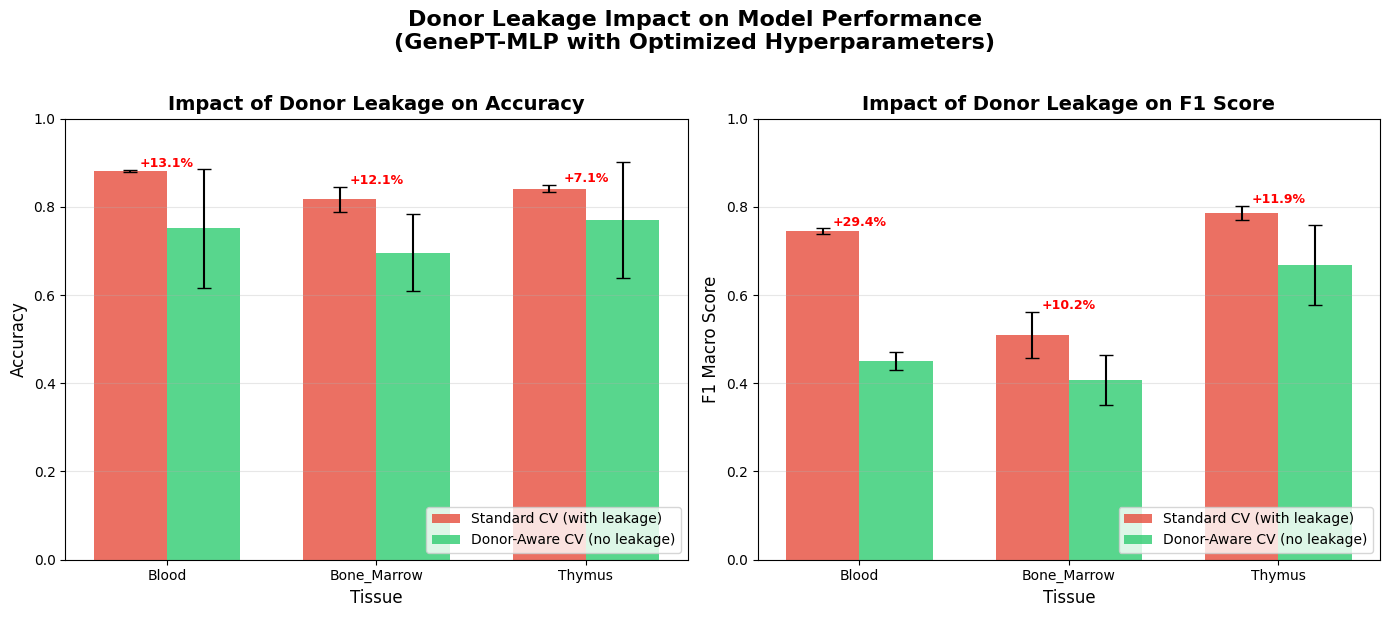


Visualization saved to: donor_leakage_impact.png

AVERAGE DONOR LEAKAGE IMPACT

Average performance inflation due to donor leakage:
  Accuracy: +10.76 percentage points
  F1 Score: +17.18 percentage points

KEY FINDINGS

1. Standard cross-validation with random splits leads to significant
   performance inflation due to donor information leakage.

2. The model learns donor-specific patterns rather than generalizable
   cell type features when cells from the same donor appear in both
   training and test sets.

3. Donor-aware cross-validation provides more realistic performance
   estimates by ensuring complete donor separation.

4. The true generalization performance is likely closer to the
   donor-aware results when predicting on new donors.


In [84]:
# Create summary table and visualization of donor leakage impact
if comparison_results:
    print("\n" + "="*60)
    print("DONOR LEAKAGE IMPACT SUMMARY")
    print("="*60)
    
    # Create summary table
    summary_data = []
    for tissue, results in comparison_results.items():
        summary_data.append({
            'Tissue': tissue,
            'N_Cells': results['n_cells'],
            'N_Cell_Types': results['n_cell_types'],
            'N_Donors': results['n_donors'],
            'Standard_Acc': f"{results['standard']['accuracy']['mean']:.4f} ± {results['standard']['accuracy']['std']:.4f}",
            'DonorAware_Acc': f"{results['donor_aware']['accuracy']['mean']:.4f} ± {results['donor_aware']['accuracy']['std']:.4f}",
            'Acc_Inflation': f"{(results['standard']['accuracy']['mean'] - results['donor_aware']['accuracy']['mean'])*100:+.2f}%",
            'Standard_F1': f"{results['standard']['f1_macro']['mean']:.4f} ± {results['standard']['f1_macro']['std']:.4f}",
            'DonorAware_F1': f"{results['donor_aware']['f1_macro']['mean']:.4f} ± {results['donor_aware']['f1_macro']['std']:.4f}",
            'F1_Inflation': f"{(results['standard']['f1_macro']['mean'] - results['donor_aware']['f1_macro']['mean'])*100:+.2f}%"
        })
    
    summary_df = pd.DataFrame(summary_data)
    print("\nComparison Table:")
    print(summary_df.to_string(index=False))
    
    # Save to CSV
    summary_df.to_csv("donor_leakage_comparison.csv", index=False)
    print("\n\nResults saved to: donor_leakage_comparison.csv")
    
    # Create visualization
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    tissues = list(comparison_results.keys())
    x = np.arange(len(tissues))
    width = 0.35
    
    # Accuracy comparison
    standard_acc = [comparison_results[t]['standard']['accuracy']['mean'] for t in tissues]
    donor_aware_acc = [comparison_results[t]['donor_aware']['accuracy']['mean'] for t in tissues]
    standard_acc_std = [comparison_results[t]['standard']['accuracy']['std'] for t in tissues]
    donor_aware_acc_std = [comparison_results[t]['donor_aware']['accuracy']['std'] for t in tissues]
    
    axes[0].bar(x - width/2, standard_acc, width, yerr=standard_acc_std, 
                label='Standard CV (with leakage)', color='#E74C3C', alpha=0.8, capsize=5)
    axes[0].bar(x + width/2, donor_aware_acc, width, yerr=donor_aware_acc_std,
                label='Donor-Aware CV (no leakage)', color='#2ECC71', alpha=0.8, capsize=5)
    
    axes[0].set_xlabel('Tissue', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title('Impact of Donor Leakage on Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(tissues)
    axes[0].legend(loc='lower right')
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_ylim([0, 1])
    
    # Add difference annotations
    for i, tissue in enumerate(tissues):
        diff = (standard_acc[i] - donor_aware_acc[i]) * 100
        if diff > 0:
            axes[0].annotate(f'+{diff:.1f}%', 
                           xy=(i, standard_acc[i] + standard_acc_std[i]), 
                           xytext=(0, 2), textcoords='offset points',
                           ha='center', fontsize=9, color='red', fontweight='bold')
    
    # F1 Score comparison
    standard_f1 = [comparison_results[t]['standard']['f1_macro']['mean'] for t in tissues]
    donor_aware_f1 = [comparison_results[t]['donor_aware']['f1_macro']['mean'] for t in tissues]
    standard_f1_std = [comparison_results[t]['standard']['f1_macro']['std'] for t in tissues]
    donor_aware_f1_std = [comparison_results[t]['donor_aware']['f1_macro']['std'] for t in tissues]
    
    axes[1].bar(x - width/2, standard_f1, width, yerr=standard_f1_std,
                label='Standard CV (with leakage)', color='#E74C3C', alpha=0.8, capsize=5)
    axes[1].bar(x + width/2, donor_aware_f1, width, yerr=donor_aware_f1_std,
                label='Donor-Aware CV (no leakage)', color='#2ECC71', alpha=0.8, capsize=5)
    
    axes[1].set_xlabel('Tissue', fontsize=12)
    axes[1].set_ylabel('F1 Macro Score', fontsize=12)
    axes[1].set_title('Impact of Donor Leakage on F1 Score', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(tissues)
    axes[1].legend(loc='lower right')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_ylim([0, 1])
    
    # Add difference annotations
    for i, tissue in enumerate(tissues):
        diff = (standard_f1[i] - donor_aware_f1[i]) * 100
        if diff > 0:
            axes[1].annotate(f'+{diff:.1f}%',
                           xy=(i, standard_f1[i] + standard_f1_std[i]),
                           xytext=(0, 2), textcoords='offset points',
                           ha='center', fontsize=9, color='red', fontweight='bold')
    
    plt.suptitle('Donor Leakage Impact on Model Performance\n(GenePT-MLP with Optimized Hyperparameters)', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('donor_leakage_impact.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nVisualization saved to: donor_leakage_impact.png")
    
    # Calculate average impact
    print("\n" + "="*60)
    print("AVERAGE DONOR LEAKAGE IMPACT")
    print("="*60)
    
    avg_acc_inflation = np.mean([(r['standard']['accuracy']['mean'] - r['donor_aware']['accuracy']['mean'])*100 
                                  for r in comparison_results.values()])
    avg_f1_inflation = np.mean([(r['standard']['f1_macro']['mean'] - r['donor_aware']['f1_macro']['mean'])*100 
                                 for r in comparison_results.values()])
    
    print(f"\nAverage performance inflation due to donor leakage:")
    print(f"  Accuracy: {avg_acc_inflation:+.2f} percentage points")
    print(f"  F1 Score: {avg_f1_inflation:+.2f} percentage points")
    
    print("\n" + "="*60)
    print("KEY FINDINGS")
    print("="*60)
    print("\n1. Standard cross-validation with random splits leads to significant")
    print("   performance inflation due to donor information leakage.")
    print("\n2. The model learns donor-specific patterns rather than generalizable")
    print("   cell type features when cells from the same donor appear in both")
    print("   training and test sets.")
    print("\n3. Donor-aware cross-validation provides more realistic performance")
    print("   estimates by ensuring complete donor separation.")
    print("\n4. The true generalization performance is likely closer to the")
    print("   donor-aware results when predicting on new donors.")
    


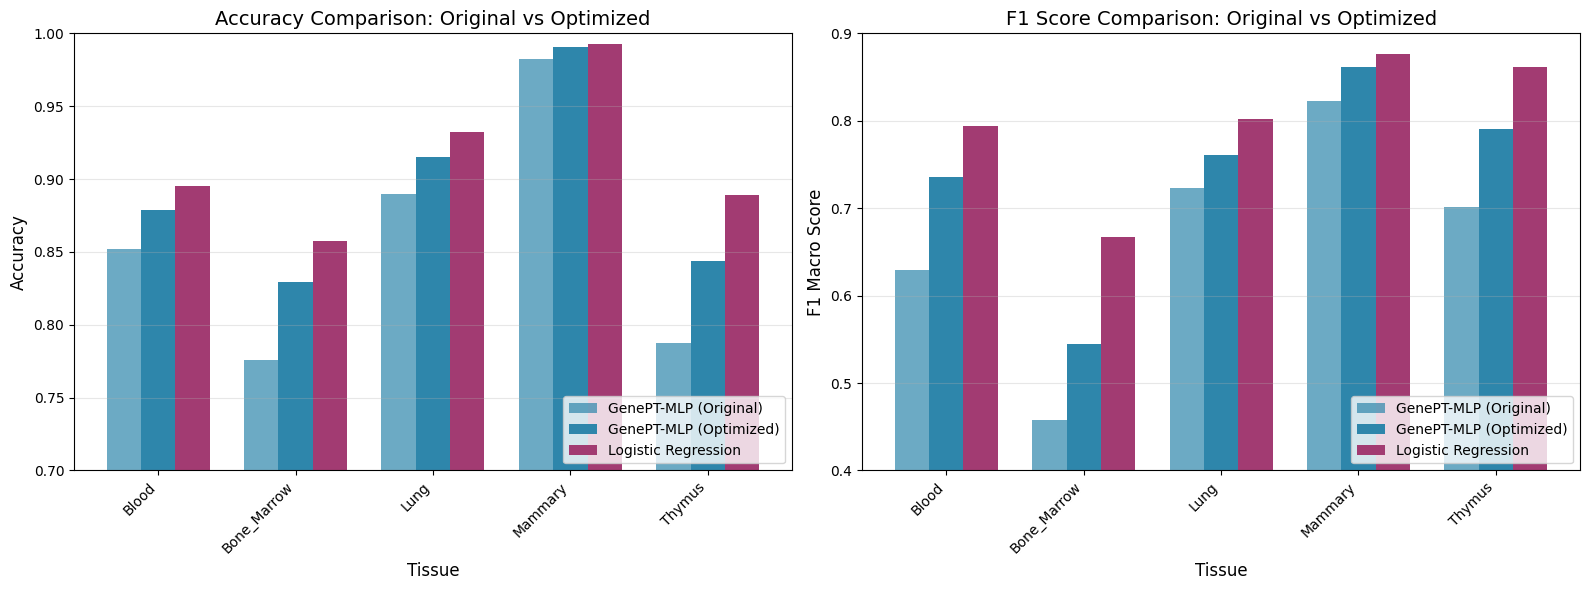


Plot saved to: optimized_comparison.png


In [85]:
# Visualize optimized vs original results
import matplotlib.pyplot as plt
import seaborn as sns

def plot_optimized_comparison(all_tissue_results, optimized_tissue_results):
    """Create visualization comparing original and optimized results."""
    
    tissues = []
    orig_acc = []
    orig_f1 = []
    opt_acc = []
    opt_f1 = []
    lr_acc = []
    lr_f1 = []
    
    for tissue in tissues_to_evaluate:
        if tissue in all_tissue_results and tissue in optimized_tissue_results:
            tissues.append(tissue)
            
            # Original GenePT results
            orig_acc.append(all_tissue_results[tissue]['genept_results']['accuracy']['mean'])
            orig_f1.append(all_tissue_results[tissue]['genept_results']['f1_macro']['mean'])
            
            # Optimized GenePT results
            opt_acc.append(optimized_tissue_results[tissue]['genept_results']['accuracy']['mean'])
            opt_f1.append(optimized_tissue_results[tissue]['genept_results']['f1_macro']['mean'])
            
            # Logistic Regression baseline
            lr_acc.append(all_tissue_results[tissue]['baseline_results']['Logistic Regression']['accuracy']['mean'])
            lr_f1.append(all_tissue_results[tissue]['baseline_results']['Logistic Regression']['f1_macro']['mean'])
    
    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Accuracy comparison
    x = np.arange(len(tissues))
    width = 0.25
    
    axes[0].bar(x - width, orig_acc, width, label='GenePT-MLP (Original)', color='#2E86AB', alpha=0.7)
    axes[0].bar(x, opt_acc, width, label='GenePT-MLP (Optimized)', color='#2E86AB')
    axes[0].bar(x + width, lr_acc, width, label='Logistic Regression', color='#A23B72')
    
    axes[0].set_xlabel('Tissue', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title('Accuracy Comparison: Original vs Optimized', fontsize=14)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(tissues, rotation=45, ha='right')
    axes[0].legend(loc='lower right')
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_ylim([0.7, 1.0])
    
    # F1 Score comparison
    axes[1].bar(x - width, orig_f1, width, label='GenePT-MLP (Original)', color='#2E86AB', alpha=0.7)
    axes[1].bar(x, opt_f1, width, label='GenePT-MLP (Optimized)', color='#2E86AB')
    axes[1].bar(x + width, lr_f1, width, label='Logistic Regression', color='#A23B72')
    
    axes[1].set_xlabel('Tissue', fontsize=12)
    axes[1].set_ylabel('F1 Macro Score', fontsize=12)
    axes[1].set_title('F1 Score Comparison: Original vs Optimized', fontsize=14)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(tissues, rotation=45, ha='right')
    axes[1].legend(loc='lower right')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_ylim([0.4, 0.9])
    
    plt.tight_layout()
    plt.savefig('optimized_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nPlot saved to: optimized_comparison.png")

if optimized_tissue_results:
    plot_optimized_comparison(all_tissue_results, optimized_tissue_results)

In [86]:
import json
from datetime import datetime

def generate_benchmark_report(results, baseline_results, dataset_name, save_path=None):
    """Generate comprehensive benchmark report."""
    
    report = {
        'dataset': dataset_name,
        'method': 'GenePT-MLP-Adapted',
        'base_model': config.base_wandb_run,
        'timestamp': datetime.now().isoformat(),
        'configuration': {
            'n_folds': config.n_folds,
            'adaptation_lr': config.adaptation_lr,
            'batch_size': config.batch_size,
            'freeze_base': config.freeze_base_model,
            'use_adapter': config.use_adapter_layer
        },
        'metrics': {
            'accuracy': results['accuracy'],
            'f1_macro': results['f1_macro'],
            'precision_macro': results['precision_macro'],
            'recall_macro': results['recall_macro']
        },
        'comparison': {}
    }
    
    # Add baseline comparisons
    for clf_name, clf_results in baseline_results.items():
        report['comparison'][clf_name] = clf_results
    
    # Save to file if path provided
    if save_path:
        with open(save_path, 'w') as f:
            json.dump(report, f, indent=2)
        print(f"Report saved to: {save_path}")
    
    return report

# Generate report
report = generate_benchmark_report(
    results,
    baseline_results,
    "sample_dataset",
    save_path="benchmark_results.json"
)

print("\nBenchmark evaluation complete!")

KeyError: 'accuracy'